In [1]:
import sys
sys.path.append(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation")  # <<< updated path here to refer to the implementation of OT-Impute and other imputation methods
import utils
import Inject_Missing_Values
import Updated_OT
import imputers
import imputers_fullyActive

In [2]:
import numpy as np
import pandas as pd
import torch
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from Inject_Missing_Values import *
# Import your original OTImputer
from imputers import OTimputer
from Updated_OT import OTimputerDropOutNoise
from imputers_fullyActive import OTimputerFullyActive

In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time

In [4]:
# Set random seed
np.random.seed(42)
torch.manual_seed(42)
rng = np.random.default_rng(42)

Loading the data

In [5]:
data = fetch_openml(data_id=151,as_frame=True)
X_full = data.data.copy()

In [6]:
# Convert categorical to numerical codes
for col in X_full.select_dtypes(include=['category', 'object']).columns:
    X_full[col] = X_full[col].astype('category').cat.codes

In [7]:
scaler = MinMaxScaler() #data [0,1]
X_full = pd.DataFrame(scaler.fit_transform(X_full), columns=X_full.columns)

Storing the clean data as Ground Truth

In [8]:
GroundTruth = X_full.copy()
X = X_full.copy()

In [9]:
print(GroundTruth)

         date       day    period  nswprice  nswdemand  vicprice  vicdemand  \
0      0.0000  0.166667  0.000000  0.056443   0.439155  0.003467   0.422915   
1      0.0000  0.166667  0.021277  0.051699   0.415055  0.003467   0.422915   
2      0.0000  0.166667  0.042553  0.051489   0.385004  0.003467   0.422915   
3      0.0000  0.166667  0.063830  0.045485   0.314639  0.003467   0.422915   
4      0.0000  0.166667  0.085106  0.042482   0.251116  0.003467   0.422915   
...       ...       ...       ...       ...        ...       ...        ...   
45307  0.9158  1.000000  0.914894  0.044224   0.340672  0.003033   0.255049   
45308  0.9158  1.000000  0.936170  0.044884   0.355549  0.003072   0.241326   
45309  0.9158  1.000000  0.957447  0.043593   0.340970  0.002983   0.247799   
45310  0.9158  1.000000  0.978723  0.066651   0.329366  0.004630   0.345417   
45311  0.9158  1.000000  1.000000  0.050679   0.288753  0.003542   0.355256   

       transfer  
0      0.414912  
1      0.414912

In [10]:
GroundTruth.nunique()

date          933
day             7
period         48
nswprice     4089
nswdemand    5266
vicprice     3798
vicdemand    2846
transfer     1878
dtype: int64

In [11]:
print("date",GroundTruth['date'].unique())
print("day",GroundTruth['day'].unique())
print("period",GroundTruth['period'].unique())
print("nswprice",GroundTruth['nswprice'].unique())
print("nswdemand",GroundTruth["nswdemand"].unique())
print("vicprice",GroundTruth['vicprice'].unique())
print("vicdemand",GroundTruth['vicdemand'].unique())
print("transfer",GroundTruth['transfer'].unique())

date [0.00000e+00 4.40000e-05 8.80000e-05 1.33000e-04 1.77000e-04 2.21000e-04
 2.65000e-04 3.10000e-04 3.54000e-04 3.98000e-04 4.42000e-04 4.87000e-04
 5.31000e-04 5.75000e-04 6.19000e-04 6.64000e-04 7.08000e-04 7.52000e-04
 7.96000e-04 8.41000e-04 8.85000e-04 9.29000e-04 9.73000e-04 1.01800e-03
 1.06200e-03 4.15900e-03 4.20300e-03 4.24800e-03 4.29200e-03 4.33600e-03
 4.38000e-03 4.42500e-03 4.46900e-03 4.51300e-03 4.55700e-03 4.60200e-03
 4.64600e-03 4.69000e-03 4.73400e-03 4.77900e-03 4.82300e-03 4.86700e-03
 4.91100e-03 4.95600e-03 5.00000e-03 5.04400e-03 5.08800e-03 5.13300e-03
 5.17700e-03 5.22100e-03 5.26500e-03 5.30900e-03 5.35400e-03 5.39800e-03
 5.44200e-03 8.58400e-03 8.62800e-03 8.67200e-03 8.71600e-03 8.76100e-03
 8.80500e-03 8.84900e-03 8.89300e-03 8.93800e-03 8.98200e-03 9.02600e-03
 9.07000e-03 9.11500e-03 9.15900e-03 9.20300e-03 9.24700e-03 9.29200e-03
 9.33600e-03 9.38000e-03 9.42400e-03 9.46900e-03 9.51300e-03 9.55700e-03
 9.60100e-03 9.64600e-03 9.69000e-03 9.73400e-

Dependecies for MAR & MNAR

In [15]:
mean_nswprice = GroundTruth["nswprice"].mean()
median_nswdemand = GroundTruth["nswdemand"].median()
mean_vicprice = GroundTruth["vicprice"].mean()
median_vicdemand = GroundTruth["vicdemand"].median()
mean_transfer = GroundTruth["transfer"].mean()
median_period = GroundTruth["period"].median()
mean_day = GroundTruth["day"].mean()  # if encoded numerically (e.g., Mon=1, ..., Sun=7)



dependencies_mar = {
    "nswprice": {
        "influencers": ["vicprice"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["vicprice"] > mean_vicprice else 0.1
    },
    "nswdemand": {
        "influencers": ["vicdemand"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["vicdemand"] > median_vicdemand else 0.1
    },
    "vicprice": {
        "influencers": ["nswprice"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nswprice"] < mean_nswprice else 0.1
    },
    "vicdemand": {
        "influencers": ["nswdemand"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nswdemand"] >= median_nswdemand else 0.1
    },
    "transfer": {
        "influencers": ["nswdemand"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nswdemand"] > median_nswdemand else 0.1
    },
    "period": {
        "influencers": ["day"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["day"] <= mean_day else 0.1
    },
    "day": {
        "influencers": ["period"],
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["period"] >= median_period else 0.1
    }
}



In [12]:
mean_nswprice = GroundTruth["nswprice"].mean()
median_nswdemand = GroundTruth["nswdemand"].median()
mean_vicprice = GroundTruth["vicprice"].mean()
median_vicdemand = GroundTruth["vicdemand"].median()
mean_transfer = GroundTruth["transfer"].mean()
median_period = GroundTruth["period"].median()
mean_day = GroundTruth["day"].mean()
median_date = pd.to_datetime(GroundTruth["date"]).map(pd.Timestamp.toordinal).median()



dependencies_mnar = {
    "nswprice": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nswprice"] < mean_nswprice else 0.1
    },
    "nswdemand": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["nswdemand"] > median_nswdemand else 0.1
    },
    "vicprice": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["vicprice"] >= mean_vicprice else 0.1
    },
    "vicdemand": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["vicdemand"] <= median_vicdemand else 0.1
    },
    "transfer": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["transfer"] >= mean_transfer else 0.1
    },
    "period": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["period"] == median_period else 0.1
    },
    "day": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if row["day"] < mean_day else 0.1
    },
    "date": {
        "condition": lambda row: True,
        "probability": lambda row: 0.5 if pd.to_datetime(row["date"]).toordinal() < median_date else 0.1
    }
}


## Running OT-Impute, OT-Rand & Batch-Impute

### MCAR

In [16]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90% missing
budgets = [0.1, 0.2, 0.3]  # Query 10%, 25%, 50% of missing cells

rng = np.random.default_rng(42)

# Create nested results dictionary
results_mcar = {
    "MSE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
    "MAE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
}


for missing_rate in missing_rates:
    generator_mcar = Inject_Missing_Values() #missing value generating
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()

    

    # Vanilla OTImputer (same for all budgets)
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter = 300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
    X_imputed = X_imputed_tensor.detach().numpy()

    baseline_mse = mean_squared_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )
    baseline_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )

    for budget_fraction in budgets:
        print(f"  -> Budget {int(budget_fraction*100)}%")

        budget = int(budget_fraction * missing_mask.values.sum())

        missing_positions = np.argwhere(missing_mask.values)
   

        # Save Vanilla
        results_mcar["MSE"][budget_fraction]["OT-Impute"].append(baseline_mse)
        results_mcar["MAE"][budget_fraction]["OT-Impute"].append(baseline_mae)

        # Random Fix
        random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
        random_selected_positions = missing_positions[random_indices]

        X_random_fixed = X_imputed.copy()
        for row_idx, col_idx in random_selected_positions:
            X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        random_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )
        random_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )

        results_mcar["MSE"][budget_fraction]["OT-Rand"].append(random_fix_mse)
        results_mcar["MAE"][budget_fraction]["OT-Rand"].append(random_fix_mae)

        # ActiveOT Fix
        imputed_runs = []
        for i in range(4):
            print(f"Run {i+1}...")
            X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
            ot_imputer = OTimputer(niter = 300, batchsize=128)
            X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
            X_imputed = X_imputed_tensor.detach().numpy()
            imputed_runs.append(X_imputed)

        imputed_stack = np.stack(imputed_runs, axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
        std_values = imputed_std[missing_mask.values]
        top_indices = np.argsort(-std_values)[:budget]
        active_selected_positions = missing_positions[top_indices]

        X_active_fixed = imputed_mean.copy()
        for row_idx, col_idx in active_selected_positions:
            X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        active_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )
        active_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )

        results_mcar["MSE"][budget_fraction]["Batch-Impute"].append(active_fix_mse)
        results_mcar["MAE"][budget_fraction]["Batch-Impute"].append(active_fix_mae)


    



# saving the result
rows = []
for metric in ["MSE", "MAE"]:
    for budget in results_mcar[metric]:
        for method in results_mcar[metric][budget]:
            values = results_mcar[metric][budget][method]
            for missing_rate_idx, value in enumerate(values):
                rows.append({
                    "Metric": metric,
                    "Budget": budget,
                    "Method": method,
                    "MissingRateIndex": missing_rate_idx,
                    metric: value
                })
#dataframe convertion
df_results_mcar = pd.DataFrame(rows)

# MSE and MAE are columns side by side
df_results_mcar = df_results_mcar.pivot_table(
    index=["MissingRateIndex", "Budget", "Method"],
    columns="Metric",
    values=["MSE", "MAE"]
).reset_index()

# Flatten multi-index columns 
df_results_mcar.columns.name = None
df_results_mcar.columns = [col if isinstance(col, str) else col[1] for col in df_results_mcar.columns]
df_results_mcar.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_results_mcar_metrics.csv", index=False)
    

  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 


Plotting results...


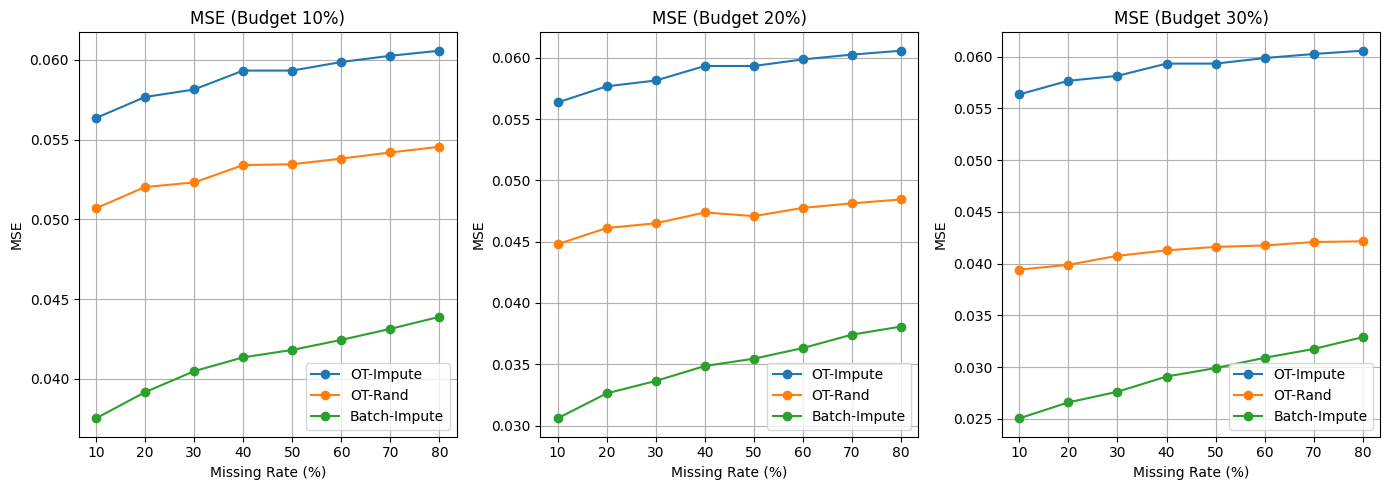

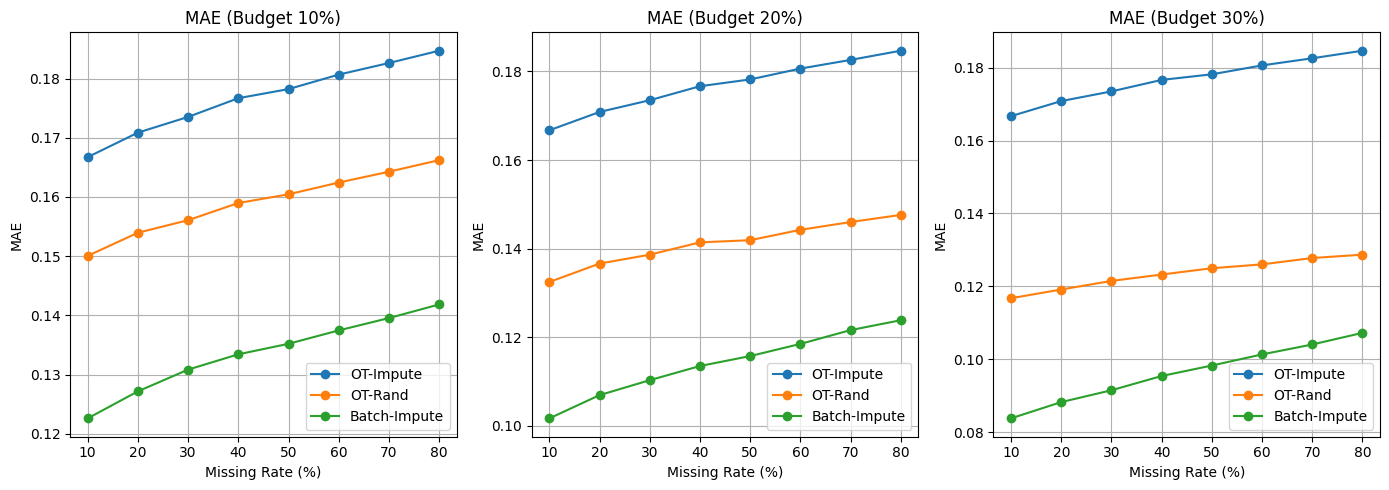

In [17]:
# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

for metric_name in ["MSE", "MAE"]:
    plt.figure(figsize=(14, 5))
    for budget_fraction in budgets:
        plt.subplot(1, len(budgets), budgets.index(budget_fraction) + 1)
        plt.plot(missing_rates , results_mcar[metric_name][budget_fraction]["OT-Impute"], label="OT-Impute", marker='o')
        plt.plot(missing_rates , results_mcar[metric_name][budget_fraction]["OT-Rand"], label="OT-Rand", marker='o')
        plt.plot(missing_rates , results_mcar[metric_name][budget_fraction]["Batch-Impute"], label="Batch-Impute", marker='o')
        plt.xlabel("Missing Rate (%)")
        plt.ylabel(metric_name)
        plt.title(f"{metric_name} (Budget {int(budget_fraction*100)}%)")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

### MAR 

In [18]:
results_mar = {
    "MSE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
    "MAE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
}
for missing_rate in missing_rates:
    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)

    total_missing_percentage_mar = miss_mar.isnull().sum().sum() / miss_mar.size * 100
    print(f"Total Missing Percentage MAR: {total_missing_percentage_mar:.2f}%")

    missing_percentage = (miss_mar.isnull().sum() / len(miss_mar)) * 100
    print(missing_percentage)

    missing_mask = miss_mar.isna()

    # Vanilla OTImputer (same for all budgets)
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter = 300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
    X_imputed = X_imputed_tensor.detach().numpy()

    baseline_mse = mean_squared_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )
    baseline_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )

    for budget_fraction in budgets:
        print(f"  -> Budget {int(budget_fraction*100)}%")

        budget = int(budget_fraction * missing_mask.values.sum())

        missing_positions = np.argwhere(missing_mask.values)
   

        # Save Vanilla
        results_mar["MSE"][budget_fraction]["OT-Impute"].append(baseline_mse)
        results_mar["MAE"][budget_fraction]["OT-Impute"].append(baseline_mae)

        # Random Fix
        random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
        random_selected_positions = missing_positions[random_indices]

        X_random_fixed = X_imputed.copy()
        for row_idx, col_idx in random_selected_positions:
            X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        random_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )
        random_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )

        results_mar["MSE"][budget_fraction]["OT-Rand"].append(random_fix_mse)
        results_mar["MAE"][budget_fraction]["OT-Rand"].append(random_fix_mae)

        # ActiveOT Fix
        imputed_runs = []
        for i in range(4):
            print(f"Run {i+1}...")
            X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
            ot_imputer = OTimputer(niter = 300, batchsize=128)
            X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
            X_imputed = X_imputed_tensor.detach().numpy()
            imputed_runs.append(X_imputed)

        imputed_stack = np.stack(imputed_runs, axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
        std_values = imputed_std[missing_mask.values]
        top_indices = np.argsort(-std_values)[:budget]
        active_selected_positions = missing_positions[top_indices]

        X_active_fixed = imputed_mean.copy()
        for row_idx, col_idx in active_selected_positions:
            X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        active_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )
        active_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )

        results_mar["MSE"][budget_fraction]["Batch-Impute"].append(active_fix_mse)
        results_mar["MAE"][budget_fraction]["Batch-Impute"].append(active_fix_mae)


    



# saving the result
rows = []
for metric in ["MSE", "MAE"]:
    for budget in results_mar[metric]:
        for method in results_mar[metric][budget]:
            values = results_mar[metric][budget][method]
            for missing_rate_idx, value in enumerate(values):
                rows.append({
                    "Metric": metric,
                    "Budget": budget,
                    "Method": method,
                    "MissingRateIndex": missing_rate_idx,
                    metric: value
                })
#dataframe convertion
df_results_mar = pd.DataFrame(rows)

# MSE and MAE are columns side by side
df_results_mar = df_results_mar.pivot_table(
    index=["MissingRateIndex", "Budget", "Method"],
    columns="Metric",
    values=["MSE", "MAE"]
).reset_index()

# Flatten multi-index columns 
df_results_mar.columns.name = None
df_results_mar.columns = [col if isinstance(col, str) else col[1] for col in df_results_mar.columns]
df_results_mar.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_results_mar_metrics.csv", index=False)
    

Total Missing Percentage MAR: 10.00%
date          0.000000
day          12.093927
period       13.206215
nswprice      7.192355
nswdemand     8.953478
vicprice     14.005120
vicdemand    12.226342
transfer     12.321239
dtype: float64
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
Total Missing Percentage MAR: 20.00%
date          0.000000
day          24.152542
period       26.469809
nswprice     14.618644
nswdemand    18.357168
vicprice     27.608581
vicdemand    24.291578
transfer     24.501236
dtype: float64
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
Total Missing Percentage MAR: 30.00%
date          0.000000
day          36.250883
period       39.170639
nswprice     23.015978
nswdemand    28.060999
vicprice     41.006797
vicdemand    36.171434
transfer     36.32


Plotting results...


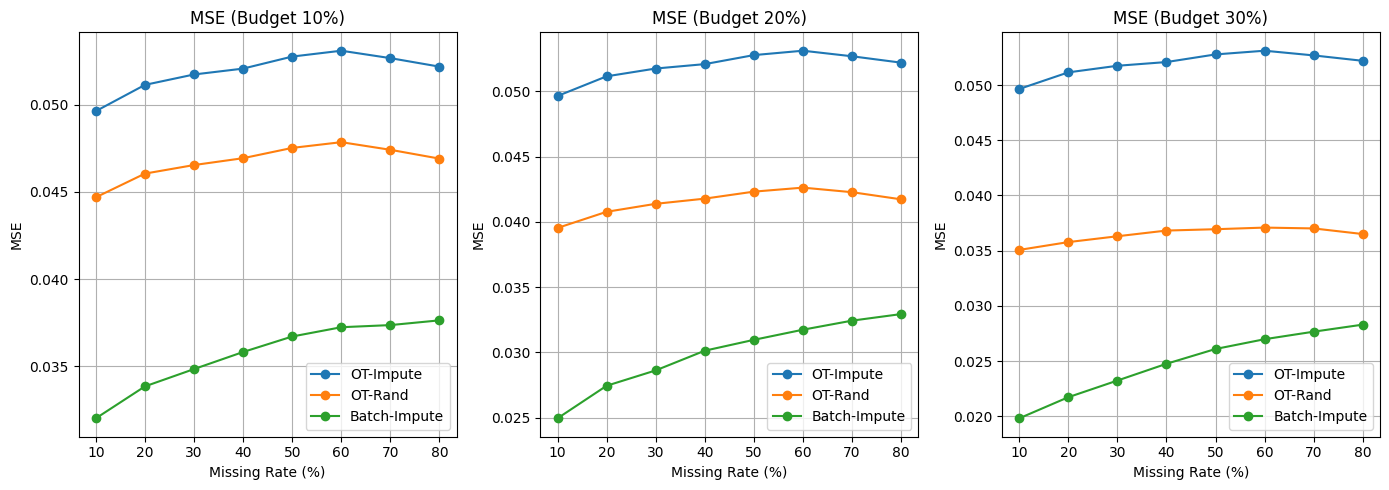

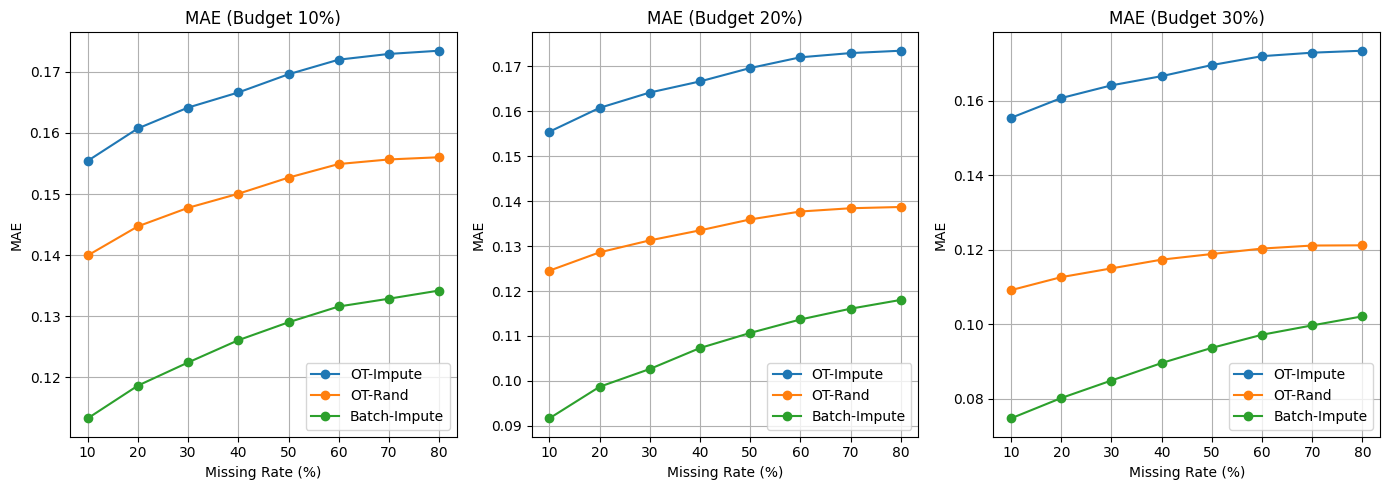

In [19]:
# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

for metric_name in ["MSE", "MAE"]:
    plt.figure(figsize=(14, 5))
    for budget_fraction in budgets:
        plt.subplot(1, len(budgets), budgets.index(budget_fraction) + 1)
        plt.plot(missing_rates, results_mar[metric_name][budget_fraction]["OT-Impute"], label="OT-Impute", marker='o')
        plt.plot(missing_rates, results_mar[metric_name][budget_fraction]["OT-Rand"], label="OT-Rand", marker='o')
        plt.plot(missing_rates, results_mar[metric_name][budget_fraction]["Batch-Impute"], label="Batch-Impute", marker='o')
        plt.xlabel("Missing Rate (%)")
        plt.ylabel(metric_name)
        plt.title(f"{metric_name} (Budget {int(budget_fraction*100)}%)")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

### MNAR

In [20]:
results_mnar = {
    "MSE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
    "MAE": {b: {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": []} for b in budgets},
}
for missing_rate in missing_rates:
    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)

    missing_mask = miss_mnar.isna()

    # Vanilla OTImputer (same for all budgets)
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter = 300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
    X_imputed = X_imputed_tensor.detach().numpy()

    baseline_mse = mean_squared_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )
    baseline_mae = mean_absolute_error(
        GroundTruth.values[missing_mask.values],
        X_imputed[missing_mask.values]
    )

    for budget_fraction in budgets:
        print(f"  -> Budget {int(budget_fraction*100)}%")

        budget = int(budget_fraction * missing_mask.values.sum())

        missing_positions = np.argwhere(missing_mask.values)
   

        # Save Vanilla
        results_mnar["MSE"][budget_fraction]["OT-Impute"].append(baseline_mse)
        results_mnar["MAE"][budget_fraction]["OT-Impute"].append(baseline_mae)

        # Random Fix
        random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
        random_selected_positions = missing_positions[random_indices]

        X_random_fixed = X_imputed.copy()
        for row_idx, col_idx in random_selected_positions:
            X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        random_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )
        random_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_random_fixed[missing_mask.values]
        )

        results_mnar["MSE"][budget_fraction]["OT-Rand"].append(random_fix_mse)
        results_mnar["MAE"][budget_fraction]["OT-Rand"].append(random_fix_mae)

        # ActiveOT Fix
        imputed_runs = []
        for i in range(4):
            print(f"Run {i+1}...")
            X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
            ot_imputer = OTimputer(niter = 300, batchsize=128)
            X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
            X_imputed = X_imputed_tensor.detach().numpy()
            imputed_runs.append(X_imputed)

        imputed_stack = np.stack(imputed_runs, axis=0)
        imputed_mean = np.nanmean(imputed_stack, axis=0)
        imputed_std = np.nanstd(imputed_stack, axis=0)
        std_values = imputed_std[missing_mask.values]
        top_indices = np.argsort(-std_values)[:budget]
        active_selected_positions = missing_positions[top_indices]

        X_active_fixed = imputed_mean.copy()
        for row_idx, col_idx in active_selected_positions:
            X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        active_fix_mse = mean_squared_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )
        active_fix_mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values],
            X_active_fixed[missing_mask.values]
        )

        results_mnar["MSE"][budget_fraction]["Batch-Impute"].append(active_fix_mse)
        results_mnar["MAE"][budget_fraction]["Batch-Impute"].append(active_fix_mae)


    



# saving the result
rows = []
for metric in ["MSE", "MAE"]:
    for budget in results_mnar[metric]:
        for method in results_mnar[metric][budget]:
            values = results_mnar[metric][budget][method]
            for missing_rate_idx, value in enumerate(values):
                rows.append({
                    "Metric": metric,
                    "Budget": budget,
                    "Method": method,
                    "MissingRateIndex": missing_rate_idx,
                    metric: value
                })
#dataframe convertion
df_results_mnar = pd.DataFrame(rows)

# MSE and MAE are columns side by side
df_results_mnar = df_results_mnar.pivot_table(
    index=["MissingRateIndex", "Budget", "Method"],
    columns="Metric",
    values=["MSE", "MAE"]
).reset_index()

# Flatten multi-index columns 
df_results_mnar.columns.name = None
df_results_mnar.columns = [col if isinstance(col, str) else col[1] for col in df_results_mnar.columns]
df_results_mnar.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_results_mnar_metrics.csv", index=False)
    

  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 20%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 30%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 10%
Run 1...
Run 2...
Run 3...
Run 4...
  -> Budget 


Plotting results...


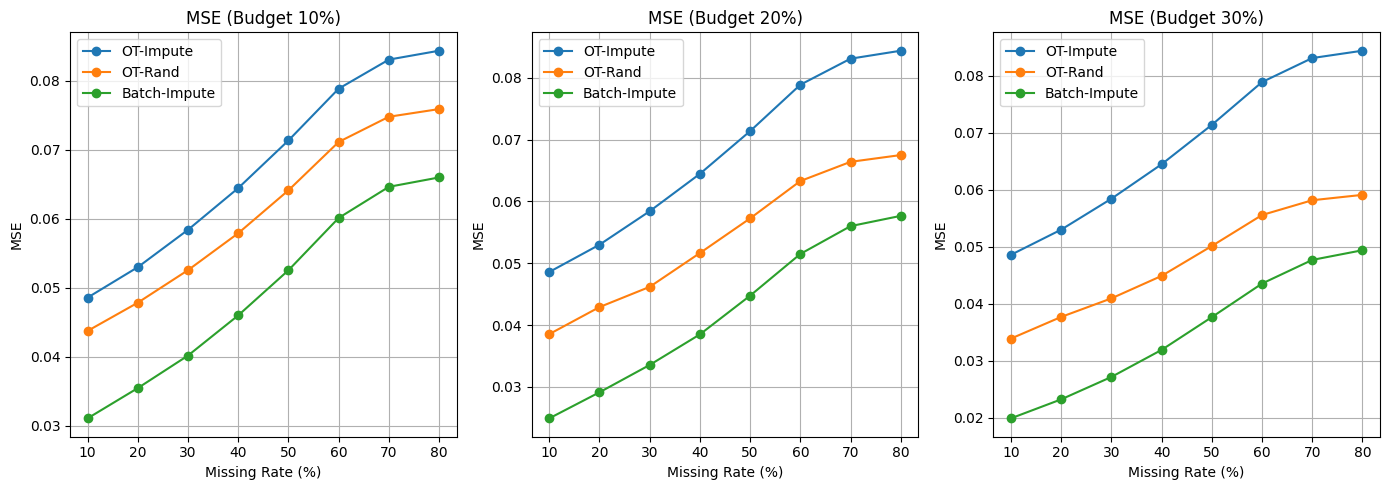

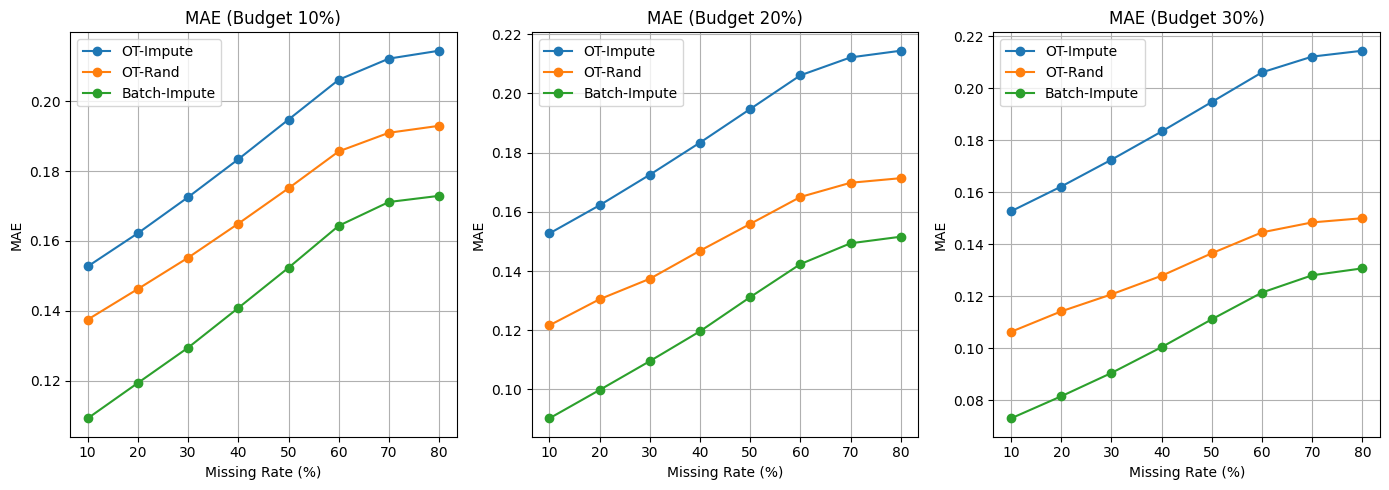

In [21]:
# --------------------------
# Plotting
# --------------------------
print("\nPlotting results...")

for metric_name in ["MSE", "MAE"]:
    plt.figure(figsize=(14, 5))
    for budget_fraction in budgets:
        plt.subplot(1, len(budgets), budgets.index(budget_fraction) + 1)
        plt.plot(missing_rates, results_mnar[metric_name][budget_fraction]["OT-Impute"], label="OT-Impute", marker='o')
        plt.plot(missing_rates, results_mnar[metric_name][budget_fraction]["OT-Rand"], label="OT-Rand", marker='o')
        plt.plot(missing_rates, results_mnar[metric_name][budget_fraction]["Batch-Impute"], label="Batch-Impute", marker='o')
        plt.xlabel("Missing Rate (%)")
        plt.ylabel(metric_name)
        plt.title(f"{metric_name} (Budget {int(budget_fraction*100)}%)")
        plt.legend()
        plt.grid(True)
    plt.tight_layout()
    plt.show()

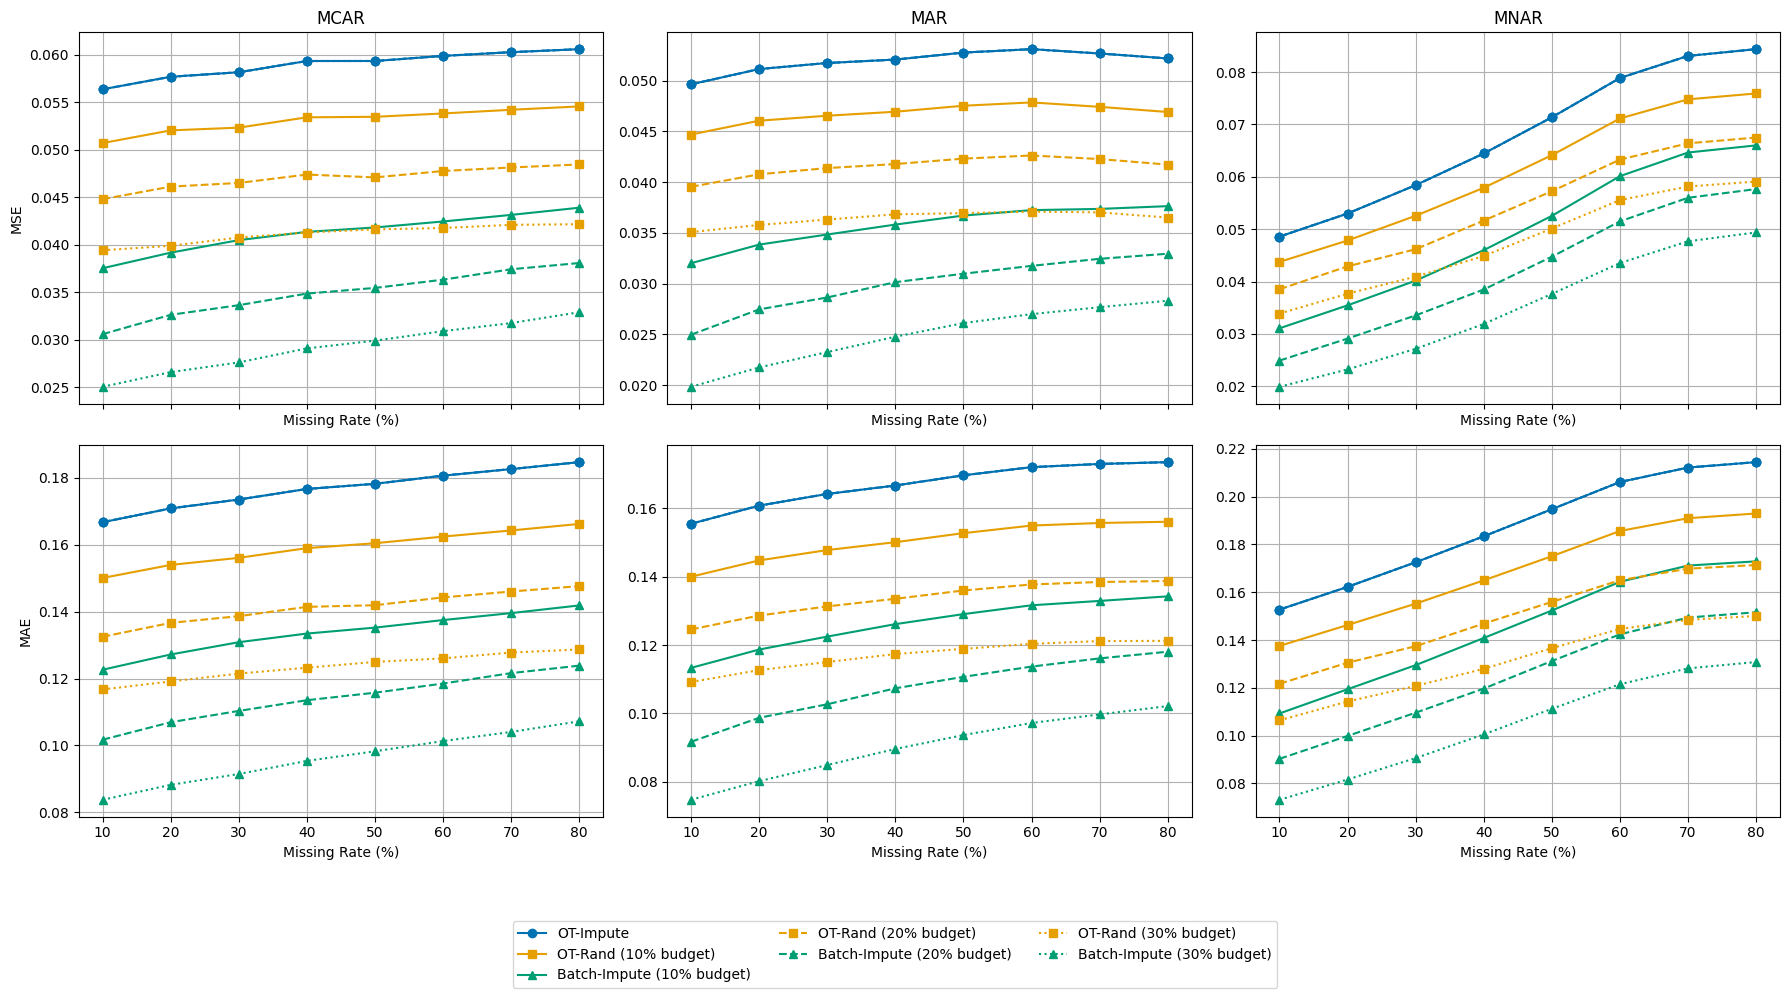

In [22]:
import matplotlib.pyplot as plt

# === Data Setup (replace these with your real data) ===
# Each pattern result should follow this format:
# results_*[metric]["budget_fraction"]["method"] = list of values
pattern_data = {
    "MCAR": results_mcar,
    "MAR": results_mar,
    "MNAR": results_mnar
}

missing_patterns = ["MCAR", "MAR", "MNAR"]
budgets = [0.1, 0.2, 0.3]
methods = ["OT-Impute", "OT-Rand", "Batch-Impute"]
missing_rates = [10, 20, 30, 40, 50, 60, 70, 80]  # Adjust as needed

# === Style Settings ===
line_styles = {0.1: '-', 0.2: '--', 0.3: ':'}
markers = {"OT-Impute": 'o', "OT-Rand": 's', "Batch-Impute": '^'}
colors = {"OT-Impute": '#0072B2', "OT-Rand": '#E69F00', "Batch-Impute": '#009E73'}  # colorblind-friendly

# === Optional: std values for error bands ===
# Format: std_data[pattern][metric][budget][method] = list of stds
# Set to None if not using
std_data = None  # or load your std_data dictionary here

# === Plotting ===
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

metrics = ["MSE", "MAE"]

vanilla_labeled = False

for row_idx, metric in enumerate(metrics):
    for col_idx, pattern in enumerate(missing_patterns):
        ax = axes[row_idx, col_idx]
    
        results = pattern_data[pattern]

        for budget in budgets:
            for method in methods:
                plot_method = "Batch-Impute" if method == "Batch-Impute" else method
                values = results[metric][budget][plot_method]

                if len(values) != len(missing_rates):
                    print(f"⚠️ Skipped: {pattern}, {metric}, {method}, budget {budget}")
                    continue

                # Plot mean line
                if method == "OT-Impute":
                    label = "OT-Impute" if not vanilla_labeled else None
                    vanilla_labeled = True
                else:
                    label = f"{method} ({int(budget * 100)}% budget)"

                

                ax.plot(
                    missing_rates,
                    values,
                    linestyle=line_styles[budget],
                    marker=markers[method],
                    color=colors[method],
                    label=label
                )


                # Optional: Error bands
                if std_data:
                    std_vals = std_data[pattern][metric][budget][method]
                    if len(std_vals) == len(values):
                        lower = [v - s for v, s in zip(values, std_vals)]
                        upper = [v + s for v, s in zip(values, std_vals)]
                        ax.fill_between(missing_rates, lower, upper, color=colors[method], alpha=0.2)

        if row_idx == 0:
            ax.set_title(pattern)
        if col_idx == 0:
            ax.set_ylabel(metric)
        ax.set_xlabel("Missing Rate (%)")
        ax.grid(True)

# === Shared Legend ===
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize='medium', bbox_to_anchor=(0.5, -0.05))

# === Main Title & Layout ===

plt.tight_layout(rect=[0, 0.07, 1, 0.95])
fig.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Cancer_matrix.pdf", bbox_inches='tight')

plt.show()


## Comarision with Baseline

MCAR Budget 0.1

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Configuration
missing_rates = np.arange(10, 90, 10)
budget_fraction = 0.1
methods = ["Mean", "KNN", "MICE", "OT-Impute", "OT-Rand", "Batch-Impute"]
all_results_comparision_mcar_b01 = []

num_runs = 5  # Repeat the whole process this many times

for run in range(num_runs):
    print(f"\n===== RUN {run + 1} / {num_runs} =====")
    for missing_rate in missing_rates:
        print(f"\n=== Missing Rate: {missing_rate}% ===")

        # Inject missing values
        generator = Inject_Missing_Values()
        X_missing, _ = generator.MCAR(X, missing_rate=missing_rate)
        missing_mask = X_missing.isna()
        missing_positions = np.argwhere(missing_mask.values)
        budget = int(budget_fraction * len(missing_positions))

        # Initialize imputers
        imputers = {
            "Mean": lambda df: df.fillna(df.mean()),
            "KNN": KNNImputer(n_neighbors=5),
            "MICE": IterativeImputer(max_iter=50, random_state=42),
            "OT-Impute": OTimputer(niter=300, batchsize=128)
        }

        mae_scores = {}

        # Basic Imputers
        for method in ["Mean", "KNN", "MICE", "OT-Impute"]:
            print(f"Running {method}...")
            try:
                if method == "Mean":
                    imputed = imputers[method](X_missing).values
                elif method == "OT-Impute":
                    Xt = torch.tensor(X_missing.values, dtype=torch.float64)
                    imputed = imputers[method].fit_transform(Xt).detach().numpy()
                else:
                    imputed = imputers[method].fit_transform(X_missing)

                mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
                mae_scores[method] = round(mae, 4)
                all_results_comparision_mcar_b01.append({
                    "Run": run,
                    "MissingRate(%)": missing_rate,
                    "Method": method,
                    "MAE": round(mae, 4)
                })
            except Exception as e:
                print(f"Error in {method}: {e}")

        # OT-RandomFix
        print("Running OT-RandomFix...")
        imputed_ot = imputers["OT-Impute"].fit_transform(torch.tensor(X_missing.values, dtype=torch.float64)).detach().numpy()
        rand_idx = np.random.choice(len(missing_positions), size=budget, replace=False)
        rand_selected = missing_positions[rand_idx]
        X_random_fixed = imputed_ot.copy()
        for r, c in rand_selected:
            X_random_fixed[r, c] = GroundTruth.values[r, c]

        mae_random = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
        mae_scores["OT-Rand"] = round(mae_random, 4)
        all_results_comparision_mcar_b01.append({
            "Run": run,
            "MissingRate(%)": missing_rate,
            "Method": "OT-Rand",
            "MAE": round(mae_random, 4)
        })

        # OT-ActiveOT (1-shot uncertainty)
        print("Running OT-ActiveOT...")
        runs = []
        for _ in range(4):
            Xt = torch.tensor(X_missing.values, dtype=torch.float64)
            runs.append(imputers["OT-Impute"].fit_transform(Xt).detach().numpy())

        stacked = np.stack(runs)
        mean_imp = np.mean(stacked, axis=0)
        std_imp = np.std(stacked, axis=0)
        std_vals = std_imp[missing_mask.values]
        top_idx = np.argsort(-std_vals)[:budget]
        active_selected = missing_positions[top_idx]
        X_active_fixed = mean_imp.copy()
        for r, c in active_selected:
            X_active_fixed[r, c] = GroundTruth.values[r, c]

        mae_active = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
        mae_scores["Batch-Impute"] = round(mae_active, 4)
        all_results_comparision_mcar_b01.append({
            "Run": run,
            "MissingRate(%)": missing_rate,
            "Method": "Batch-Impute",
            "MAE": round(mae_active, 4)
        })

        # Print per-missing-rate result
        print("\n📊 MAE Comparison:")
        df_mae = pd.DataFrame([
            {"Method": k, "MAE": v} for k, v in mae_scores.items()
        ]).sort_values("MAE")
        print(df_mae.to_string(index=False))

# === Save all runs ===
df_comparision_mcar_b01 = pd.DataFrame(all_results_comparision_mcar_b01)
df_comparision_mcar_b01.to_csv(
    r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_mae_base_comparison_mcar_budget01_allruns.csv",
    index=False
)


===== RUN 1 / 5 =====

=== Missing Rate: 10% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
         KNN 0.1240
        MICE 0.1250
Batch-Impute 0.1358
        Mean 0.1489
     OT-Rand 0.1592
   OT-Impute 0.1780

=== Missing Rate: 20% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
        MICE 0.1280
Batch-Impute 0.1367
         KNN 0.1398
        Mean 0.1484
     OT-Rand 0.1598
   OT-Impute 0.1782

=== Missing Rate: 30% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1381
         KNN 0.1407
        MICE 0.1410
        Mean 0.1481
     OT-Rand 0.1610
   OT-Impute 0.1785

=== Missing Rate: 40% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1402
        MICE 0.1411
         KNN 0.1418
        Mean 0.1484
     OT-Rand 0.1620
   OT-Impute 0.1805

=== Missing Rate: 50% ===
Running Mean...
Running KNN...
Running MICE...


...

Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
Batch-Impute 0.1412
        MICE 0.1419
         KNN 0.1420
        Mean 0.1486
     OT-Rand 0.1633
   OT-Impute 0.1815

=== Missing Rate: 60% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
         KNN 0.1405
Batch-Impute 0.1423
        MICE 0.1433
        Mean 0.1484
     OT-Rand 0.1641
   OT-Impute 0.1816

=== Missing Rate: 70% ===
Running Mean...
Running KNN...
Running MICE...


c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\impute\_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
         KNN 0.1405
Batch-Impute 0.1434
        MICE 0.1469
        Mean 0.1484
     OT-Rand 0.1645
   OT-Impute 0.1829

=== Missing Rate: 80% ===
Running Mean...
Running KNN...
Running MICE...
Running OT-Impute...
Running OT-RandomFix...
Running OT-ActiveOT...

📊 MAE Comparison:
      Method    MAE
         KNN 0.1432
Batch-Impute 0.1438
        MICE 0.1483
        Mean 0.1483
     OT-Rand 0.1653
   OT-Impute 0.1838


MAR

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Configuration
missing_rates = np.arange(10, 90, 10)
budget_fraction = 0.1
methods = ["Mean", "KNN", "MICE", "OT-Impute", "OT-Rand", "Batch-Impute"]
all_results_comparision_mar_b01 = []

num_runs = 5  # Repeat the whole process this many times

for run in range(num_runs):
    print(f"\n===== RUN {run + 1} / {num_runs} =====")
    for missing_rate in missing_rates:
        print(f"\n=== Missing Rate: {missing_rate}% ===")

        # Inject missing values
        generator = Inject_Missing_Values()
        X_missing, _ = generator.MAR(X, missing_rate=missing_rate,dependencies=dependencies_mar)
        missing_mask = X_missing.isna()
        missing_positions = np.argwhere(missing_mask.values)
        budget = int(budget_fraction * len(missing_positions))

        # Initialize imputers
        imputers = {
            "Mean": lambda df: df.fillna(df.mean()),
            "KNN": KNNImputer(n_neighbors=5),
            "MICE": IterativeImputer(max_iter=50, random_state=42),
            "OT-Impute": OTimputer(niter=300, batchsize=128)
        }

        mae_scores = {}

        # Basic Imputers
        for method in ["Mean", "KNN", "MICE", "OT-Impute"]:
            print(f"Running {method}...")
            try:
                if method == "Mean":
                    imputed = imputers[method](X_missing).values
                elif method == "OT-Impute":
                    Xt = torch.tensor(X_missing.values, dtype=torch.float64)
                    imputed = imputers[method].fit_transform(Xt).detach().numpy()
                else:
                    imputed = imputers[method].fit_transform(X_missing)

                mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
                mae_scores[method] = round(mae, 4)
                all_results_comparision_mar_b01.append({
                    "Run": run,
                    "MissingRate(%)": missing_rate,
                    "Method": method,
                    "MAE": round(mae, 4)
                })
            except Exception as e:
                print(f"Error in {method}: {e}")

        # OT-RandomFix
        print("Running OT-RandomFix...")
        imputed_ot = imputers["OT-Impute"].fit_transform(torch.tensor(X_missing.values, dtype=torch.float64)).detach().numpy()
        rand_idx = np.random.choice(len(missing_positions), size=budget, replace=False)
        rand_selected = missing_positions[rand_idx]
        X_random_fixed = imputed_ot.copy()
        for r, c in rand_selected:
            X_random_fixed[r, c] = GroundTruth.values[r, c]

        mae_random = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
        mae_scores["OT-Rand"] = round(mae_random, 4)
        all_results_comparision_mar_b01.append({
            "Run": run,
            "MissingRate(%)": missing_rate,
            "Method": "OT-Rand",
            "MAE": round(mae_random, 4)
        })

        # OT-ActiveOT (1-shot uncertainty)
        print("Running OT-ActiveOT...")
        runs = []
        for _ in range(4):
            Xt = torch.tensor(X_missing.values, dtype=torch.float64)
            runs.append(imputers["OT-Impute"].fit_transform(Xt).detach().numpy())

        stacked = np.stack(runs)
        mean_imp = np.mean(stacked, axis=0)
        std_imp = np.std(stacked, axis=0)
        std_vals = std_imp[missing_mask.values]
        top_idx = np.argsort(-std_vals)[:budget]
        active_selected = missing_positions[top_idx]
        X_active_fixed = mean_imp.copy()
        for r, c in active_selected:
            X_active_fixed[r, c] = GroundTruth.values[r, c]

        mae_active = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
        mae_scores["Batch-Impute"] = round(mae_active, 4)
        all_results_comparision_mar_b01.append({
            "Run": run,
            "MissingRate(%)": missing_rate,
            "Method": "Batch-Impute",
            "MAE": round(mae_active, 4)
        })

        # Print per-missing-rate result
        print("\n📊 MAE Comparison:")
        df_mae = pd.DataFrame([
            {"Method": k, "MAE": v} for k, v in mae_scores.items()
        ]).sort_values("MAE")
        print(df_mae.to_string(index=False))

# === Save all runs ===
df_comparision_mar_b01 = pd.DataFrame(all_results_comparision_mar_b01)
df_comparision_mar_b01.to_csv(
    r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_mae_base_comparison_mar_budget01_allruns.csv",
    index=False
)

MNAR

In [ ]:
import numpy as np
import pandas as pd
import torch
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_absolute_error

# Configuration
missing_rates = np.arange(10, 90, 10)
budget_fraction = 0.1
methods = ["Mean", "KNN", "MICE", "OT-Impute", "OT-Rand", "Batch-Impute"]
all_results_comparision_mnar_b01 = []

num_runs = 5  # Repeat the whole process this many times

for run in range(num_runs):
    print(f"\n===== RUN {run + 1} / {num_runs} =====")
    for missing_rate in missing_rates:
        print(f"\n=== Missing Rate: {missing_rate}% ===")

        # Inject missing values
        generator = Inject_Missing_Values()
        X_missing, _ = generator.MNAR(X, missing_rate=missing_rate,dependencies=dependencies_mnar)
        missing_mask = X_missing.isna()
        missing_positions = np.argwhere(missing_mask.values)
        budget = int(budget_fraction * len(missing_positions))

        # Initialize imputers
        imputers = {
            "Mean": lambda df: df.fillna(df.mean()),
            "KNN": KNNImputer(n_neighbors=5),
            "MICE": IterativeImputer(max_iter=50, random_state=42),
            "OT-Impute": OTimputer(niter=300, batchsize=128)
        }

        mae_scores = {}

        # Basic Imputers
        for method in ["Mean", "KNN", "MICE", "OT-Impute"]:
            print(f"Running {method}...")
            try:
                if method == "Mean":
                    imputed = imputers[method](X_missing).values
                elif method == "OT-Impute":
                    Xt = torch.tensor(X_missing.values, dtype=torch.float64)
                    imputed = imputers[method].fit_transform(Xt).detach().numpy()
                else:
                    imputed = imputers[method].fit_transform(X_missing)

                mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
                mae_scores[method] = round(mae, 4)
                all_results_comparision_mnar_b01.append({
                    "Run": run,
                    "MissingRate(%)": missing_rate,
                    "Method": method,
                    "MAE": round(mae, 4)
                })
            except Exception as e:
                print(f"Error in {method}: {e}")

        # OT-RandomFix
        print("Running OT-RandomFix...")
        imputed_ot = imputers["OT-Impute"].fit_transform(torch.tensor(X_missing.values, dtype=torch.float64)).detach().numpy()
        rand_idx = np.random.choice(len(missing_positions), size=budget, replace=False)
        rand_selected = missing_positions[rand_idx]
        X_random_fixed = imputed_ot.copy()
        for r, c in rand_selected:
            X_random_fixed[r, c] = GroundTruth.values[r, c]

        mae_random = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
        mae_scores["OT-Rand"] = round(mae_random, 4)
        all_results_comparision_mnar_b01.append({
            "Run": run,
            "MissingRate(%)": missing_rate,
            "Method": "OT-Rand",
            "MAE": round(mae_random, 4)
        })

        # OT-ActiveOT (1-shot uncertainty)
        print("Running OT-ActiveOT...")
        runs = []
        for _ in range(4):
            Xt = torch.tensor(X_missing.values, dtype=torch.float64)
            runs.append(imputers["OT-Impute"].fit_transform(Xt).detach().numpy())

        stacked = np.stack(runs)
        mean_imp = np.mean(stacked, axis=0)
        std_imp = np.std(stacked, axis=0)
        std_vals = std_imp[missing_mask.values]
        top_idx = np.argsort(-std_vals)[:budget]
        active_selected = missing_positions[top_idx]
        X_active_fixed = mean_imp.copy()
        for r, c in active_selected:
            X_active_fixed[r, c] = GroundTruth.values[r, c]

        mae_active = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
        mae_scores["Batch-Impute"] = round(mae_active, 4)
        all_results_comparision_mnar_b01.append({
            "Run": run,
            "MissingRate(%)": missing_rate,
            "Method": "Batch-Impute",
            "MAE": round(mae_active, 4)
        })

        # Print per-missing-rate result
        print("\n📊 MAE Comparison:")
        df_mae = pd.DataFrame([
            {"Method": k, "MAE": v} for k, v in mae_scores.items()
        ]).sort_values("MAE")
        print(df_mae.to_string(index=False))

# === Save all runs ===
df_comparision_mnar_b01 = pd.DataFrame(all_results_comparision_mnar_b01)
df_comparision_mnar_b01.to_csv(
    r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_mae_base_comparison_mnar_budget01_allruns.csv",
    index=False
)

## Optimization

### MAE vd Dropout noise for BatchOpt-Impute MCAR

In [30]:
missing_rate = 30  # 10% to 90%
budget_fractions = 0.1  # fixed 10%
dropOutNoises = [0.0, 0.00001, 0.00005, 0.0001, 0.0005,
                 0.001, 0.005, 0.01, 0.05,
                 0.1]



results_mcar_opt_dropOut = {d: [] for d in dropOutNoises}
n_runs = 10  # or 10


for dropOutNoise in dropOutNoises:
    print(f"\n=== Dropout Noise: {dropOutNoise} ===")
    for run in range(n_runs):
        print(f"  Run {run+1}/{n_runs}")
        
        generator_mcar = Inject_Missing_Values()
        miss_mcar, index_mcar = generator_mcar.MCAR(X, missing_rate=missing_rate)
        missing_mask = miss_mcar.isna()
        missing_positions = np.argwhere(missing_mask.values)
        budget = int(budget_fraction * missing_mask.values.sum())

        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputerDropOutNoise(
            niter=300,
            batchsize=128,
            dropout_noise_scale=dropOutNoise
        )
        X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
            X_missing_tensor, track_confidence=True, snapshot_interval=10
        )

        imputed_mean_opt = X_imputed_tensor.detach().numpy()
        std_values_opt = confidence_scores.detach().numpy()
        top_indices_opt = np.argsort(-std_values_opt)[:budget]
        active_selected_positions_opt = missing_positions[top_indices_opt]

        X_activeopt_fixed = imputed_mean_opt.copy()
        for row_idx, col_idx in active_selected_positions_opt:
            X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values]
        )
        results_mcar_opt_dropOut[dropOutNoise].append(mae)





# Flatten results into a list of records
records_mcar_dropOut = []

for noise, maes in results_mcar_opt_dropOut.items():
    for run_id, mae in enumerate(maes):
        records_mcar_dropOut.append({
            "DropoutNoise": noise,
            "Run": run_id + 1,
            "MAE": mae
        })

# Convert to DataFrame
df_results = pd.DataFrame(records_mcar_dropOut)

# Save to CSV
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_MCAR_DropoutNoise_MAE_Results.csv", index=False)
print("Results saved to DropoutNoise_MAE_Results.csv")




=== Dropout Noise: 0.0 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 1e-05 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 5e-05 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.0001 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.0005 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.001 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout Noise: 0.005 ===
  Run 1/10
  Run 2/10
  Run 3/10
  Run 4/10
  Run 5/10
  Run 6/10
  Run 7/10
  Run 8/10
  Run 9/10
  Run 10/10

=== Dropout 

### MAE vd Dropout noise for BatchOpt-Impute MAR

In [33]:
missing_rate = 30  # 10% to 90%
budget_fractions = 0.1  # fixed 10%
dropOutNoises = [0.0, 0.00001, 0.00005, 0.0001, 0.0005,
                 0.001, 0.005, 0.01, 0.05,
                 0.1]



results_mar_opt_dropOut = {d: [] for d in dropOutNoises}
n_runs = 5  # or 10


for dropOutNoise in dropOutNoises:
    print(f"\n=== Dropout Noise: {dropOutNoise} ===")
    for run in range(n_runs):
        print(f"  Run {run+1}/{n_runs}")
        
        generator_mar = Inject_Missing_Values()
        miss_mar, index_mar = generator_mar.MAR(X, missing_rate=missing_rate,dependencies=dependencies_mar)
        missing_mask = miss_mar.isna()
        missing_positions = np.argwhere(missing_mask.values)
        budget = int(budget_fraction * missing_mask.values.sum())

        X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
        ot_imputer = OTimputerDropOutNoise(
            niter=300,
            batchsize=128,
            dropout_noise_scale=dropOutNoise
        )
        X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
            X_missing_tensor, track_confidence=True, snapshot_interval=10
        )

        imputed_mean_opt = X_imputed_tensor.detach().numpy()
        std_values_opt = confidence_scores.detach().numpy()
        top_indices_opt = np.argsort(-std_values_opt)[:budget]
        active_selected_positions_opt = missing_positions[top_indices_opt]

        X_activeopt_fixed = imputed_mean_opt.copy()
        for row_idx, col_idx in active_selected_positions_opt:
            X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values]
        )
        results_mar_opt_dropOut[dropOutNoise].append(mae)





# Flatten results into a list of records
records_mar_dropOut = []

for noise, maes in results_mar_opt_dropOut.items():
    for run_id, mae in enumerate(maes):
        records_mar_dropOut.append({
            "DropoutNoise": noise,
            "Run": run_id + 1,
            "MAE": mae
        })

# Convert to DataFrame
df_results = pd.DataFrame(records_mar_dropOut)

# Save to CSV
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_MAR_DropoutNoise_MAE_Results.csv", index=False)





=== Dropout Noise: 0.0 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 1e-05 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 5e-05 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 0.0001 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 0.0005 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 0.001 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 0.005 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 0.01 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 0.05 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 0.1 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5


### MAE vd Dropout noise for BatchOpt-Impute MNAR

In [34]:
missing_rate = 30  # 10% to 90%
budget_fractions = 0.1  # fixed 10%
dropOutNoises = [0.0, 0.00001, 0.00005, 0.0001, 0.0005,
                 0.001, 0.005, 0.01, 0.05,
                 0.1]



results_mnar_opt_dropOut = {d: [] for d in dropOutNoises}
n_runs = 5  # or 10


for dropOutNoise in dropOutNoises:
    print(f"\n=== Dropout Noise: {dropOutNoise} ===")
    for run in range(n_runs):
        print(f"  Run {run+1}/{n_runs}")
        
        generator_mnar = Inject_Missing_Values()
        miss_mnar, index_mnar = generator_mnar.MNAR(X, missing_rate=missing_rate,dependencies=dependencies_mnar)
        missing_mask = miss_mnar.isna()
        missing_positions = np.argwhere(missing_mask.values)
        budget = int(budget_fraction * missing_mask.values.sum())

        X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
        ot_imputer = OTimputerDropOutNoise(
            niter=300,
            batchsize=128,
            dropout_noise_scale=dropOutNoise
        )
        X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
            X_missing_tensor, track_confidence=True, snapshot_interval=10
        )

        imputed_mean_opt = X_imputed_tensor.detach().numpy()
        std_values_opt = confidence_scores.detach().numpy()
        top_indices_opt = np.argsort(-std_values_opt)[:budget]
        active_selected_positions_opt = missing_positions[top_indices_opt]

        X_activeopt_fixed = imputed_mean_opt.copy()
        for row_idx, col_idx in active_selected_positions_opt:
            X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

        mae = mean_absolute_error(
            GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values]
        )
        results_mnar_opt_dropOut[dropOutNoise].append(mae)





# Flatten results into a list of records
records_mnar_dropOut = []

for noise, maes in results_mnar_opt_dropOut.items():
    for run_id, mae in enumerate(maes):
        records_mnar_dropOut.append({
            "DropoutNoise": noise,
            "Run": run_id + 1,
            "MAE": mae
        })

# Convert to DataFrame
df_results = pd.DataFrame(records_mnar_dropOut)

# Save to CSV
df_results.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_MNAR_DropoutNoise_MAE_Results.csv", index=False)
print("Results saved to DropoutNoise_MAE_Results.csv")




=== Dropout Noise: 0.0 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 1e-05 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 5e-05 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 0.0001 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 0.0005 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 0.001 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 0.005 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 0.01 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 0.05 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5

=== Dropout Noise: 0.1 ===
  Run 1/5
  Run 2/5
  Run 3/5
  Run 4/5
  Run 5/5
Results saved to DropoutNoise_MAE_Results.csv


MCAR

In [32]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mcar_opt = {
    "MSE": {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": [], "BatchOpt-Impute": []},
    "MAE": {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": [], "BatchOpt-Impute": []},
    "Time": {"Batch-Impute": [], "BatchOpt-Impute": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mcar = Inject_Missing_Values()
    miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=missing_rate)

    missing_mask = miss_mcar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mcar_opt["MSE"]["OT-Impute"].append(baseline_mse)
    results_mcar_opt["MAE"]["OT-Impute"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mcar_opt["MSE"]["OT-Rand"].append(random_fix_mse)
    results_mcar_opt["MAE"]["OT-Rand"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=300, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mcar_opt["MSE"]["Batch-Impute"].append(active_fix_mse)
    results_mcar_opt["MAE"]["Batch-Impute"].append(active_fix_mae)
    results_mcar_opt["Time"]["Batch-Impute"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=300,
        batchsize=128,
        dropout_noise_scale= 0.002
         )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval = 10
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mcar_opt["MSE"]["BatchOpt-Impute"].append(activeopt_fix_mse)
    results_mcar_opt["MAE"]["BatchOpt-Impute"].append(activeopt_fix_mae)
    results_mcar_opt["Time"]["BatchOpt-Impute"].append(activeotopt_time)


# Save MAE results
mae_df = pd.DataFrame(results_mcar_opt["MAE"])
mae_df.insert(0, "MissingRate", missing_rates)
mae_df.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_MCAR_OPT_Results_MAE.csv", index=False)

# Save Runtime results
time_df = pd.DataFrame(results_mcar_opt["Time"])
time_df.insert(0, "MissingRate", missing_rates)
time_df.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_MCAR_OPT_Results_Time.csv", index=False)









=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===


MAR

In [37]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mar_opt = {
    "MSE": {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": [], "BatchOpt-Impute": []},
    "MAE": {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": [], "BatchOpt-Impute": []},
    "Time": {"Batch-Impute": [], "BatchOpt-Impute": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mar = Inject_Missing_Values()
    miss_mar, index_mar = generator_mar.MAR(X,missing_rate=missing_rate,dependencies=dependencies_mar)

    missing_mask = miss_mar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mar_opt["MSE"]["OT-Impute"].append(baseline_mse)
    results_mar_opt["MAE"]["OT-Impute"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mar_opt["MSE"]["OT-Rand"].append(random_fix_mse)
    results_mar_opt["MAE"]["OT-Rand"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=300, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mar_opt["MSE"]["Batch-Impute"].append(active_fix_mse)
    results_mar_opt["MAE"]["Batch-Impute"].append(active_fix_mae)
    results_mar_opt["Time"]["Batch-Impute"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=300,
        batchsize=128,
        dropout_noise_scale= 0.001
         )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval = 10
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mar_opt["MSE"]["BatchOpt-Impute"].append(activeopt_fix_mse)
    results_mar_opt["MAE"]["BatchOpt-Impute"].append(activeopt_fix_mae)
    results_mar_opt["Time"]["BatchOpt-Impute"].append(activeotopt_time)


# Save MAE results
mae_df = pd.DataFrame(results_mar_opt["MAE"])
mae_df.insert(0, "MissingRate", missing_rates)
mae_df.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_MAR_OPT_Results_MAE.csv", index=False)

# Save Runtime results
time_df = pd.DataFrame(results_mar_opt["Time"])
time_df.insert(0, "MissingRate", missing_rates)
time_df.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_MAR_OPT_Results_Time.csv", index=False)









=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===


MNAR

In [38]:
missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mnar_opt = {
    "MSE": {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": [], "BatchOpt-Impute": []},
    "MAE": {"OT-Impute": [], "OT-Rand": [], "Batch-Impute": [], "BatchOpt-Impute": []},
    "Time": {"Batch-Impute": [], "BatchOpt-Impute": []}
}

for missing_rate in missing_rates:
    print(f"\n=== Missing rate: {int(missing_rate)}% ===")

    generator_mnar = Inject_Missing_Values()
    miss_mnar, index_mnar = generator_mnar.MNAR(X,missing_rate=missing_rate,dependencies=dependencies_mnar)

    missing_mask = miss_mnar.isna()
    missing_positions = np.argwhere(missing_mask.values)

    budget = int(budget_fraction * missing_mask.values.sum())

    # -------------------
    # Vanilla OTImputer, running OT just once
    # -------------------
    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    ot_imputer = OTimputer(niter=300, batchsize=128)
    X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)

    imputed = X_imputed_tensor.detach().numpy() #not mean just the normal imp matrix

    baseline_mse = mean_squared_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])
    baseline_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], imputed[missing_mask.values])

    results_mnar_opt["MSE"]["OT-Impute"].append(baseline_mse)
    results_mnar_opt["MAE"]["OT-Impute"].append(baseline_mae)


    # -------------------
    # Random Fix
    # -------------------
    random_indices = rng.choice(len(missing_positions), size=budget, replace=False)
    random_selected_positions = missing_positions[random_indices]

    X_random_fixed = imputed.copy()
    for row_idx, col_idx in random_selected_positions:
        X_random_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    random_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])
    random_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_random_fixed[missing_mask.values])

    results_mnar_opt["MSE"]["OT-Rand"].append(random_fix_mse)
    results_mnar_opt["MAE"]["OT-Rand"].append(random_fix_mae)

    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------

    start_time = time.time()

    imputed_runs = []
    for _ in range(4):
        X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
        ot_imputer = OTimputer(niter=300, batchsize=128)
        X_imputed_tensor = ot_imputer.fit_transform(X_missing_tensor)
        X_imputed = X_imputed_tensor.detach().numpy()
        imputed_runs.append(X_imputed)

    imputed_stack = np.stack(imputed_runs, axis=0)
    imputed_mean_active = np.nanmean(imputed_stack, axis=0)
    imputed_std_active = np.nanstd(imputed_stack, axis=0)

    std_values_active = imputed_std_active[missing_mask.values]
    top_indices = np.argsort(-std_values_active)[:budget]
    active_selected_positions = missing_positions[top_indices]

    X_active_fixed = imputed_mean_active.copy()
    for row_idx, col_idx in active_selected_positions:
        X_active_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    active_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])
    active_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_active_fixed[missing_mask.values])

    end_time = time.time()
    activeot_time = end_time - start_time

    results_mnar_opt["MSE"]["Batch-Impute"].append(active_fix_mse)
    results_mnar_opt["MAE"]["Batch-Impute"].append(active_fix_mae)
    results_mnar_opt["Time"]["Batch-Impute"].append(activeot_time)


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
    start_time = time.time()

    X_missing_tensor = torch.tensor(miss_mnar.values, dtype=torch.float64)
    ot_imputer = OTimputerDropOutNoise(
        niter=300,
        batchsize=128,
        dropout_noise_scale= 0.0001
         )
    X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval = 10
    )

    imputed_mean_opt = X_imputed_tensor.detach().numpy()
    std_values_opt = confidence_scores.detach().numpy()

    top_indices_opt = np.argsort(-std_values_opt)[:budget]
    active_selected_positions_opt = missing_positions[top_indices_opt]

    X_activeopt_fixed = imputed_mean_opt.copy()
    for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

    activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
    activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

    end_time = time.time()
    activeotopt_time = end_time - start_time

    results_mnar_opt["MSE"]["BatchOpt-Impute"].append(activeopt_fix_mse)
    results_mnar_opt["MAE"]["BatchOpt-Impute"].append(activeopt_fix_mae)
    results_mnar_opt["Time"]["BatchOpt-Impute"].append(activeotopt_time)


# Save MAE results
mae_df = pd.DataFrame(results_mnar_opt["MAE"])
mae_df.insert(0, "MissingRate", missing_rates)
mae_df.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_MNAR_OPT_Results_MAE.csv", index=False)

# Save Runtime results
time_df = pd.DataFrame(results_mnar_opt["Time"])
time_df.insert(0, "MissingRate", missing_rates)
time_df.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_MNAR_OPT_Results_Time.csv", index=False)



=== Missing rate: 10% ===

=== Missing rate: 20% ===

=== Missing rate: 30% ===

=== Missing rate: 40% ===

=== Missing rate: 50% ===

=== Missing rate: 60% ===

=== Missing rate: 70% ===

=== Missing rate: 80% ===


## Optimization

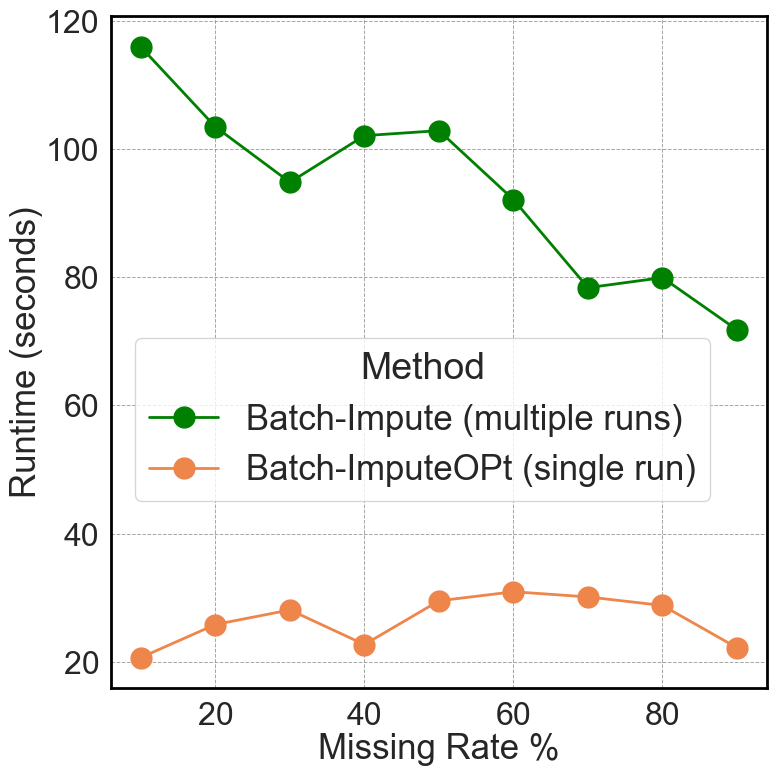

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set seaborn style and palette to match previous plots
sns.set(style="whitegrid", font_scale=1.2)
palette = sns.color_palette("muted")

# Assign consistent colors from the muted palette
color_ot_oneshot = palette[0]  # Typically blue
color_ot_oneshotopt = palette[1]  # Typically orange

# Font sizes and style configs
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
line_width = 2
marker_size = 15
y_min = 0.13
y_max = 0.17

# rcParams update for font sizes
plt.rcParams.update({
    'axes.titlesize': x_label_fontsize,
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

# Create the figure
plt.figure(figsize=(8, 8))

# Plot with consistent colors and styles
plt.plot(missing_rates, results_mcar_opt["Time"]["OT-OneShot"], 
         label="Batch-Impute (multiple runs)", 
         marker='o', color="green", linewidth=line_width, markersize=marker_size)

plt.plot(missing_rates, results_mcar_opt["Time"]["OT-OneShotOpt"], 
         label="BatchOpt-Impute (single run)", 
         marker='o', color=color_ot_oneshotopt, linewidth=line_width, markersize=marker_size)

# Labels and ticks
plt.xlabel("Missing Rate %", fontsize=x_label_fontsize,labelpad=2,fontweight='regular')
plt.ylabel("Runtime (seconds)", fontsize=y_label_fontsize,labelpad=2,fontweight='regular')
plt.xticks(fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# Grid lines
plt.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

# Border styling
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)
ax.tick_params(axis='y', width=1.5, length=5)


# Legend
plt.legend(title="Method", fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize,loc="center left",bbox_to_anchor=(0.01, 0.4),frameon=True)

# Save the figure
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\BCancer_MCAR_OptComparision_time.pdf", format="pdf", bbox_inches='tight')
plt.show()


## Fully Active

MCAR

In [ ]:
generator_mcar = Inject_Missing_Values()
X_missing, index_mcar = generator_mcar.MCAR(X, missing_rate=30)
mask = X_missing.isna()
missing_pos = np.argwhere(mask.values)

results_fullyActive_mcar = []
max_k = 15
budget_fractions = [0.1, 0.2, 0.3]

for budget_fraction in budget_fractions:
    print(f"\n===== Running for Budget Fraction: {budget_fraction} =====")
    budget = int(budget_fraction * len(missing_pos))

    for k in range(1, max_k + 1):
        print(f"\nRunning iterative ActiveFix with k={k} steps...")
        start = time.time()
        current_X = X_missing.copy()
        fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
        budget_per_iter = budget // k

        if budget_per_iter == 0:
            print(f"  Skipping k={k} (budget too small per iteration)")
            continue

        intermediate_mae = []
        unique_queried_cells = set()
        avg_std_per_iteration = []

        for step in range(k):
            print(f"  Iteration {step+1}/{k}...")

            # Start from the original missing data with fixed values filled in
            initial_X = X_missing.values.copy()
            initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

            # Run OTimputer 4 times to obtain aggregated imputed values
            X_runs = []
            for _ in range(4):
                Xt = torch.tensor(initial_X, dtype=torch.float64)
                X_imp = OTimputerFullyActive(niter=100, batchsize=64).fit_transform(Xt).detach().numpy()
                X_runs.append(X_imp)

            # Aggregate the imputed values (mean and std)
            X_stack = np.stack(X_runs)
            X_mean = np.mean(X_stack, axis=0)
            X_std = np.std(X_stack, axis=0)

            # Update the imputed values with the aggregated mean, keeping fixed values intact
            current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

            # Identify uncertain cells not fixed yet
            candidates = np.argwhere(mask.values & ~fixed_mask)
            std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

            # Sort the standard deviations in descending order and select the top uncertain cells
            top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
            selected_pos = candidates[top_idx]

            # Update unique queried cells and average std for this iteration
            unique_queried_cells.update([tuple(pos) for pos in selected_pos])
            avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
            avg_std_per_iteration.append(avg_std)

            print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
            print(f"    X_std (max value): {np.max(X_std)}")
            print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

            # Query the oracle and update the dataset
            if selected_pos.size > 0:
                rows, cols = zip(*selected_pos)
                current_X.values[rows, cols] = GroundTruth.values[rows, cols]
                fixed_mask[rows, cols] = True  # Mark these cells as fixed

            # Calculate intermediate MAE after each iteration
            mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
            intermediate_mae.append(mae_iter)
            print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

        elapsed = time.time() - start
        mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        num_unique = len(unique_queried_cells)
        avg_std_total = np.mean(avg_std_per_iteration)

        results_fullyActive_mcar.append({
            'k': k,
            'BudgetFraction': budget_fraction,
            'MAE': mae,
            'Runtime': elapsed,
            'UniqueQueried': num_unique,
            'AvgStdQueried': avg_std_total
        })
        print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

# Convert results to DataFrame and display
df_iter_mcar = pd.DataFrame(results_fullyActive_mcar)
print("\nFinal Results:")
print(df_iter_mcar)

df_iter_mcar = pd.DataFrame(results_fullyActive_mcar)
print("\nFinal Results:")
print(df_iter_mcar)

# Save the results to CSV
df_iter_mcar.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_iterative_activeFix_results_MCAR.csv", index=False)
print("Results saved to German_iterative_activeFix_results.csv.")



===== Running for Budget Fraction: 0.1 =====

Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 108749
    X_std (max value): 0.3354905174034777
    Avg Std of Queried Cells: 0.1762
    Intermediate MAE after iteration 1: 0.1299
  Final MAE: 0.1299, Time: 359.69s, Unique Queried: 10874, Avg Std: 0.1762

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 108749
    X_std (max value): 0.3511771474146015
    Avg Std of Queried Cells: 0.1958
    Intermediate MAE after iteration 1: 0.1408
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT i

c:\Users\zhossai3\AppData\Local\Programs\Python\Python312\Lib\site-packages\geomloss\samples_loss.py:47: SyntaxWarning: invalid escape sequence '\i'
  """Creates a criterion that computes distances between sampled measures on a vector space.


KeyboardInterrupt: 

MAR

In [ ]:
generator_mar = Inject_Missing_Values()
X_missing, index_mar = generator_mar.MAR(X, missing_rate=30,dependencies=dependencies_mar)
mask = X_missing.isna()
missing_pos = np.argwhere(mask.values)

results_fullyActive_mar = []
max_k = 15
budget_fractions = [0.1, 0.2, 0.3]

for budget_fraction in budget_fractions:
    print(f"\n===== Running for Budget Fraction: {budget_fraction} =====")
    budget = int(budget_fraction * len(missing_pos))

    for k in range(1, max_k + 1):
        print(f"\nRunning iterative ActiveFix with k={k} steps...")
        start = time.time()
        current_X = X_missing.copy()
        fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
        budget_per_iter = budget // k

        if budget_per_iter == 0:
            print(f"  Skipping k={k} (budget too small per iteration)")
            continue

        intermediate_mae = []
        unique_queried_cells = set()
        avg_std_per_iteration = []

        for step in range(k):
            print(f"  Iteration {step+1}/{k}...")

            # Start from the original missing data with fixed values filled in
            initial_X = X_missing.values.copy()
            initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

            # Run OTimputer 4 times to obtain aggregated imputed values
            X_runs = []
            for _ in range(4):
                Xt = torch.tensor(initial_X, dtype=torch.float64)
                X_imp = OTimputerFullyActive(niter=100, batchsize=64).fit_transform(Xt).detach().numpy()
                X_runs.append(X_imp)

            # Aggregate the imputed values (mean and std)
            X_stack = np.stack(X_runs)
            X_mean = np.mean(X_stack, axis=0)
            X_std = np.std(X_stack, axis=0)

            # Update the imputed values with the aggregated mean, keeping fixed values intact
            current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

            # Identify uncertain cells not fixed yet
            candidates = np.argwhere(mask.values & ~fixed_mask)
            std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

            # Sort the standard deviations in descending order and select the top uncertain cells
            top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
            selected_pos = candidates[top_idx]

            # Update unique queried cells and average std for this iteration
            unique_queried_cells.update([tuple(pos) for pos in selected_pos])
            avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
            avg_std_per_iteration.append(avg_std)

            print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
            print(f"    X_std (max value): {np.max(X_std)}")
            print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

            # Query the oracle and update the dataset
            if selected_pos.size > 0:
                rows, cols = zip(*selected_pos)
                current_X.values[rows, cols] = GroundTruth.values[rows, cols]
                fixed_mask[rows, cols] = True  # Mark these cells as fixed

            # Calculate intermediate MAE after each iteration
            mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
            intermediate_mae.append(mae_iter)
            print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

        elapsed = time.time() - start
        mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        num_unique = len(unique_queried_cells)
        avg_std_total = np.mean(avg_std_per_iteration)

        results_fullyActive_mar.append({
            'k': k,
            'BudgetFraction': budget_fraction,
            'MAE': mae,
            'Runtime': elapsed,
            'UniqueQueried': num_unique,
            'AvgStdQueried': avg_std_total
        })
        print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

df_iter_mar = pd.DataFrame(results_fullyActive_mar)
print("\nFinal Results:")
print(df_iter_mar)

df_iter_mar = pd.DataFrame(results_fullyActive_mar)
print("\nFinal Results:")
print(df_iter_mar)

# Save the results to CSV
df_iter_mar.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_iterative_activeFix_results_MAR.csv", index=False)




Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 205136
    X_std (max value): 0.36055470058033967
    Avg Std of Queried Cells: 0.1461
    Intermediate MAE after iteration 1: 0.1474
  Final MAE: 0.1474, Time: 11.34s, Unique Queried: 20513, Avg Std: 0.1461

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 205136
    X_std (max value): 0.27599415600441707
    Avg Std of Queried Cells: 0.1590
    Intermediate MAE after iteration 1: 0.1557
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (no

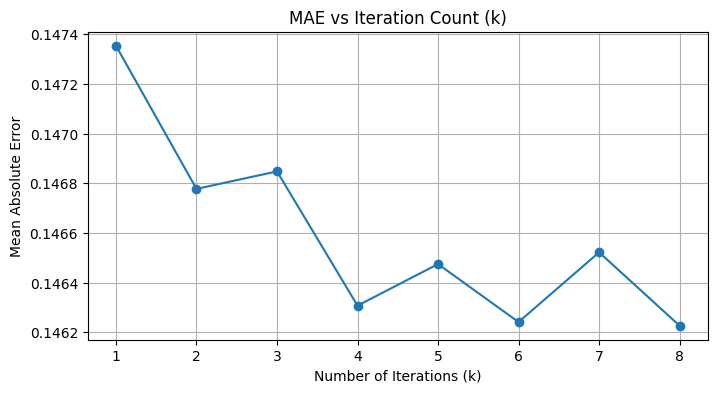

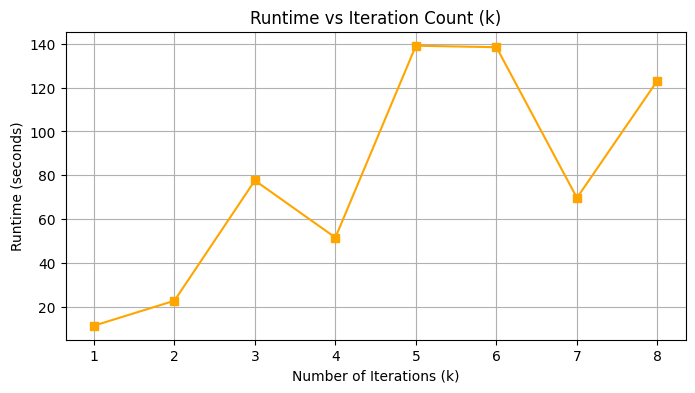

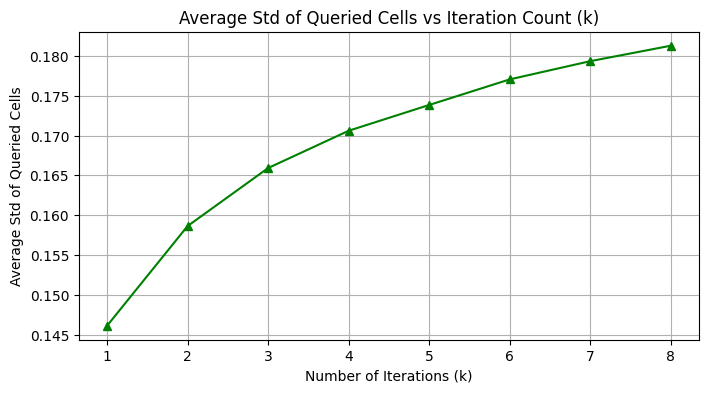

In [ ]:
# Plot MAE vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mar['k'], df_iter_mar['MAE'], marker='o', label='MAE')
plt.title("MAE vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.show()

# Plot Runtime vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mar['k'], df_iter_mar['Runtime'], marker='s', label='Runtime', color='orange')
plt.title("Runtime vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Runtime (seconds)")
plt.grid(True)
plt.show()

# Plot Avg Std vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mar['k'], df_iter_mar['AvgStdQueried'], marker='^', label='Avg Std of Queried', color='green')
plt.title("Average Std of Queried Cells vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Average Std of Queried Cells")
plt.grid(True)
plt.show()

MNAR

In [ ]:
generator_mnar = Inject_Missing_Values()
X_missing, index_mcar = generator_mcar.MNAR(X, missing_rate=30,dependencies=dependencies_mnar)
mask = X_missing.isna()
missing_pos = np.argwhere(mask.values)

results_fullyActive_mnar = []
max_k = 15
budget_fractions = [0.1, 0.2, 0.3]

for budget_fraction in budget_fractions:
    print(f"\n===== Running for Budget Fraction: {budget_fraction} =====")
    budget = int(budget_fraction * len(missing_pos))

    for k in range(1, max_k + 1):
        print(f"\nRunning iterative ActiveFix with k={k} steps...")
        start = time.time()
        current_X = X_missing.copy()
        fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
        budget_per_iter = budget // k

        if budget_per_iter == 0:
            print(f"  Skipping k={k} (budget too small per iteration)")
            continue

        intermediate_mae = []
        unique_queried_cells = set()
        avg_std_per_iteration = []

        for step in range(k):
            print(f"  Iteration {step+1}/{k}...")

            # Start from the original missing data with fixed values filled in
            initial_X = X_missing.values.copy()
            initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

            # Run OTimputer 4 times to obtain aggregated imputed values
            X_runs = []
            for _ in range(4):
                Xt = torch.tensor(initial_X, dtype=torch.float64)
                X_imp = OTimputerFullyActive(niter=100, batchsize=64).fit_transform(Xt).detach().numpy()
                X_runs.append(X_imp)

            # Aggregate the imputed values (mean and std)
            X_stack = np.stack(X_runs)
            X_mean = np.mean(X_stack, axis=0)
            X_std = np.std(X_stack, axis=0)

            # Update the imputed values with the aggregated mean, keeping fixed values intact
            current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

            # Identify uncertain cells not fixed yet
            candidates = np.argwhere(mask.values & ~fixed_mask)
            std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

            # Sort the standard deviations in descending order and select the top uncertain cells
            top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
            selected_pos = candidates[top_idx]

            # Update unique queried cells and average std for this iteration
            unique_queried_cells.update([tuple(pos) for pos in selected_pos])
            avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
            avg_std_per_iteration.append(avg_std)

            print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
            print(f"    X_std (max value): {np.max(X_std)}")
            print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

            # Query the oracle and update the dataset
            if selected_pos.size > 0:
                rows, cols = zip(*selected_pos)
                current_X.values[rows, cols] = GroundTruth.values[rows, cols]
                fixed_mask[rows, cols] = True  # Mark these cells as fixed

            # Calculate intermediate MAE after each iteration
            mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
            intermediate_mae.append(mae_iter)
            print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

        elapsed = time.time() - start
        mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        num_unique = len(unique_queried_cells)
        avg_std_total = np.mean(avg_std_per_iteration)

        results_fullyActive_mnar.append({
            'k': k,
            'BudgetFraction': budget_fraction,
            'MAE': mae,
            'Runtime': elapsed,
            'UniqueQueried': num_unique,
            'AvgStdQueried': avg_std_total
        })
        print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

# Convert results to DataFrame and display
df_iter_mnar = pd.DataFrame(results_fullyActive_mnar)
print("\nFinal Results:")
print(df_iter_mnar)

df_iter_mnar = pd.DataFrame(results_fullyActive_mnar)
print("\nFinal Results:")
print(df_iter_mnar)

# Save the results to CSV
df_iter_mnar.to_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_iterative_activeFix_results_MNAR.csv", index=False)




Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 205136
    X_std (max value): 0.2741122672710596
    Avg Std of Queried Cells: 0.1462
    Intermediate MAE after iteration 1: 0.1782
  Final MAE: 0.1782, Time: 29.53s, Unique Queried: 20513, Avg Std: 0.1462

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 205136
    X_std (max value): 0.2629870274483607
    Avg Std of Queried Cells: 0.1597
    Intermediate MAE after iteration 1: 0.1881
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-

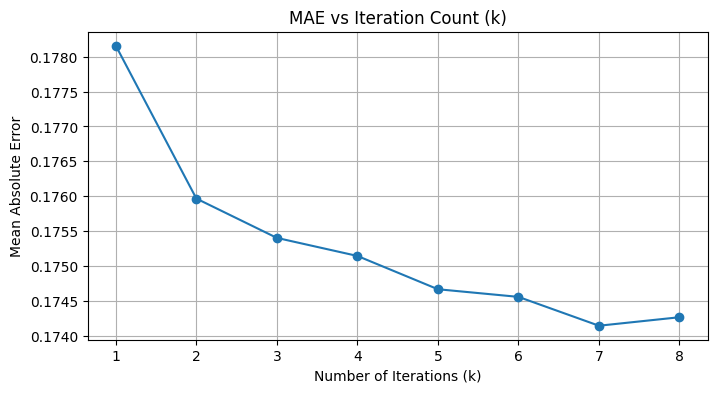

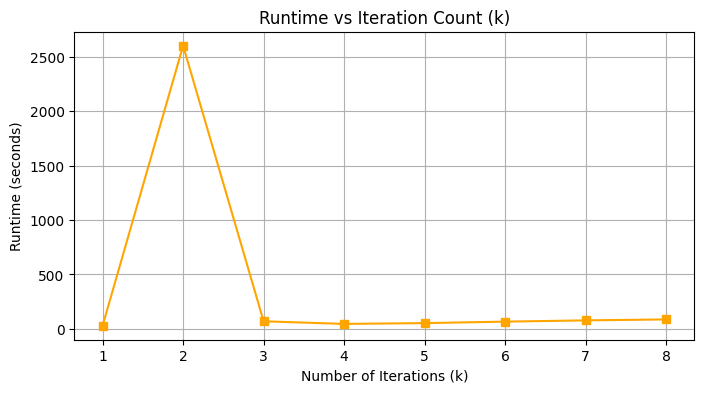

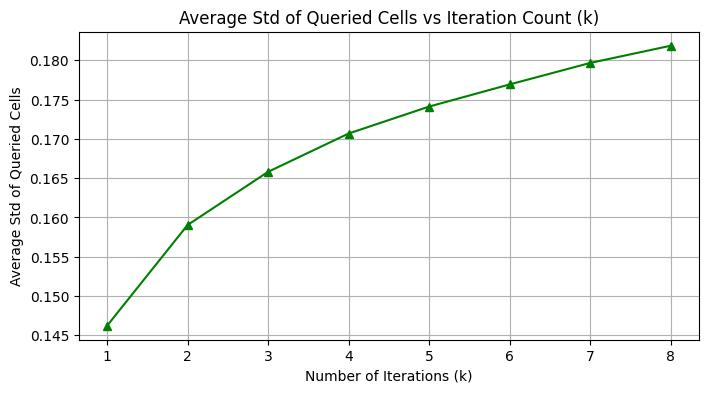

In [ ]:
# Plot MAE vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mnar['k'], df_iter_mnar['MAE'], marker='o', label='MAE')
plt.title("MAE vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.show()

# Plot Runtime vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mnar['k'], df_iter_mnar['Runtime'], marker='s', label='Runtime', color='orange')
plt.title("Runtime vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Runtime (seconds)")
plt.grid(True)
plt.show()

# Plot Avg Std vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mnar['k'], df_iter_mnar['AvgStdQueried'], marker='^', label='Avg Std of Queried', color='green')
plt.title("Average Std of Queried Cells vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Average Std of Queried Cells")
plt.grid(True)
plt.show()

In [ ]:
    #missing_rates = np.arange(10, 90, 10)  # 10% to 90%
budget_fraction = 0.1  # fixed 10%

results_mcar_opt_time = {
        "k":1,
        "MAE": {"OT-OneShotOpt": []},
        "Time": {"OT-OneShotOpt": []}
    }


 

generator_mcar = Inject_Missing_Values()
miss_mcar, index_mcar = generator_mcar.MCAR(X,missing_rate=30)

missing_mask = miss_mcar.isna()
missing_positions = np.argwhere(missing_mask.values)

budget = int(budget_fraction * missing_mask.values.sum())

   
  
    # -------------------
    # ActiveOT (external std - multiple runs)
    # -------------------



   


    # -------------------
    # ActiveOTOpt (internal std - track_confidence=True) using internal std to sort confidence
    # -------------------
start_time = time.time()

X_missing_tensor = torch.tensor(miss_mcar.values, dtype=torch.float64)
ot_imputer = OTimputerDropOutNoise(
        niter=300,
        batchsize=128,
        dropout_noise_scale= 0.001
         )
X_imputed_tensor, confidence_scores = ot_imputer.fit_transform(
        X_missing_tensor, track_confidence=True, snapshot_interval=10
    )

imputed_mean_opt = X_imputed_tensor.detach().numpy()
std_values_opt = confidence_scores.detach().numpy()

top_indices_opt = np.argsort(-std_values_opt)[:budget]
active_selected_positions_opt = missing_positions[top_indices_opt]

X_activeopt_fixed = imputed_mean_opt.copy()
for row_idx, col_idx in active_selected_positions_opt:
        X_activeopt_fixed[row_idx, col_idx] = GroundTruth.values[row_idx, col_idx]

activeopt_fix_mse = mean_squared_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])
activeopt_fix_mae = mean_absolute_error(GroundTruth.values[missing_mask.values], X_activeopt_fixed[missing_mask.values])

end_time = time.time()
activeotopt_time = end_time - start_time

    
results_mcar_opt_time["MAE"]["OT-OneShotOpt"].append(activeopt_fix_mae)
results_mcar_opt_time["Time"]["OT-OneShotOpt"].append(activeotopt_time)





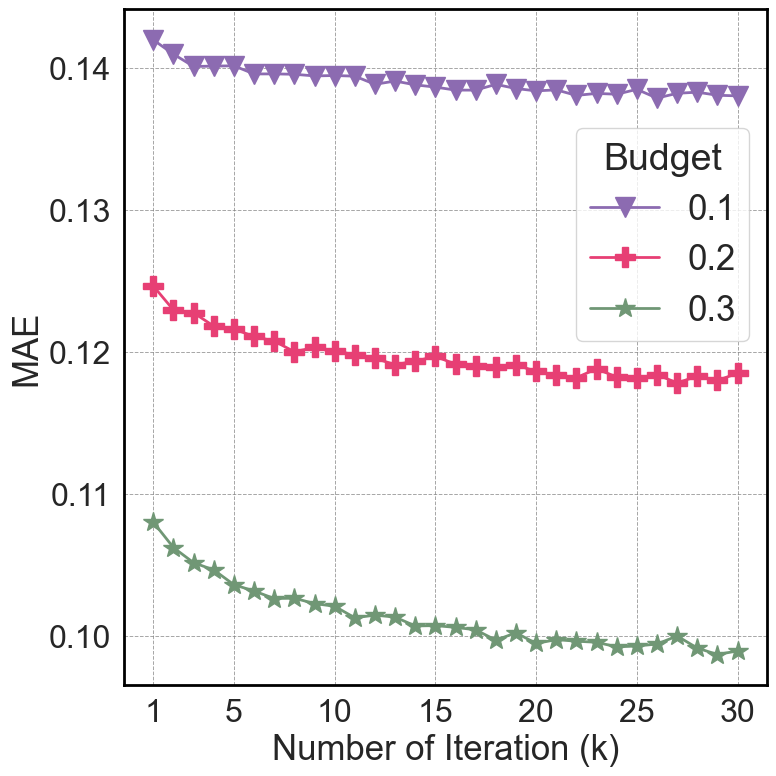

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use a pastel palette
#pastel_palette = sns.color_palette("pastel")
custom_colors = [
    "#8C6BB1",  # dark lavender
    "#E73F74",  # vivid pinkish red
     "#709775"  # plum
]

# Define distinct markers for each budget
markers = ['v', 'P', '*', 'X']
unique_budgets = sorted(df_iter_mcar['BudgetFraction'].unique())
num_lines = len(unique_budgets)
#colors = pastel_palette[:num_lines]  # Use pastel colors
colors = custom_colors[:num_lines]

# Custom font sizes (from second code block)
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
marker_size = 15

# Apply consistent seaborn and matplotlib style
sns.set(style="whitegrid", font_scale=1.2)
plt.rcParams.update({
    'axes.titlesize': x_label_fontsize,
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

# Create plot
plt.figure(figsize=(8, 8))

for i, budget in enumerate(unique_budgets):
    subset = df_iter_mcar[df_iter_mcar['BudgetFraction'] == budget]
    plt.plot(
        subset['k'], subset['MAE'],
        marker=markers[i % len(markers)],
        label=f"{budget:.1f}",
        linewidth=2,
        color=colors[i],
        markersize=marker_size
    )

# Axis labels
plt.xlabel("Number of Iteration (k)", fontsize=x_label_fontsize)
plt.ylabel("MAE", fontsize=y_label_fontsize)

# Filter x-ticks to reduce clutter and make them integers
k_ticks = sorted(df_iter_mcar["k"].unique())
filtered_k_ticks = [int(k) for k in k_ticks if int(k) % 5 == 0 or k == min(k_ticks) or k == max(k_ticks)]
plt.xticks(ticks=filtered_k_ticks, labels=[str(k) for k in filtered_k_ticks], fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# Grid and thick black border
plt.grid(True, linestyle='--', linewidth=0.7, color='gray', alpha=0.7)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Legend
plt.legend(title="Budget", fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize,
           loc='upper right', bbox_to_anchor=(1, 0.85), frameon=True)

# Final layout
plt.tight_layout()

# Save figure
plt.savefig(
    r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Cancer_iterative_MAE_vs_k_MCAR.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()


In [ ]:
generator_mcar = Inject_Missing_Values()
X_missing, index_mcar = generator_mcar.MCAR(X,missing_rate=30)
mask = X_missing.isna()

results_fullyActive_mcar = []
max_k = 4
budget_fraction = 0.1
missing_pos = np.argwhere(mask.values)
budget = int(budget_fraction * len(missing_pos))
max_k = 30
for k in range(1, max_k + 1):
    print(f"\nRunning iterative ActiveFix with k={k} steps...")
    start = time.time()
    current_X = X_missing.copy()
    fixed_mask = np.zeros_like(mask.values, dtype=bool)  # Tracks fixed values
    budget_per_iter = budget // k

    intermediate_mae = []
    unique_queried_cells = set()
    avg_std_per_iteration = []

    for step in range(k):
        print(f"  Iteration {step+1}/{k}...")

        # Start from the original missing data with fixed values filled in
        initial_X = X_missing.values.copy()
        initial_X[fixed_mask] = GroundTruth.values[fixed_mask]

        # Run OTimputer 4 times to obtain aggregated imputed values
        X_runs = []
        for _ in range(4):
            Xt = torch.tensor(initial_X, dtype=torch.float64)
            X_imp = OTimputerFullyActive(niter=300, batchsize=128).fit_transform(Xt).detach().numpy()
            X_runs.append(X_imp)

        # Aggregate the imputed values (mean and std)
        X_stack = np.stack(X_runs)
        X_mean = np.mean(X_stack, axis=0)
        X_std = np.std(X_stack, axis=0)

        # Update the imputed values with the aggregated mean, keeping fixed values intact
        current_X.values[mask.values & ~fixed_mask] = X_mean[mask.values & ~fixed_mask]

        # Identify uncertain cells not fixed yet
        candidates = np.argwhere(mask.values & ~fixed_mask)
        std_vals = np.array([X_std[tuple(pos)] for pos in candidates])

        # Sort the standard deviations in descending order and select the top uncertain cells
        top_idx = np.argsort(-std_vals)[:min(budget_per_iter, len(std_vals))]
        selected_pos = candidates[top_idx]

        # Update unique queried cells and average std for this iteration
        unique_queried_cells.update([tuple(pos) for pos in selected_pos])
        avg_std = np.mean([X_std[tuple(pos)] for pos in selected_pos])
        avg_std_per_iteration.append(avg_std)

        print(f"    X_std (non-zero elements): {np.count_nonzero(X_std)}")
        print(f"    X_std (max value): {np.max(X_std)}")
        print(f"    Avg Std of Queried Cells: {avg_std:.4f}")

        # Query the oracle and update the dataset
        if selected_pos.size > 0:  # Check if the list is not empty
            rows, cols = zip(*selected_pos)
            current_X.values[rows, cols] = GroundTruth.values[rows, cols]
            fixed_mask[rows, cols] = True  # Mark these cells as fixed

        # Calculate intermediate MAE after each iteration
        mae_iter = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
        intermediate_mae.append(mae_iter)
        print(f"    Intermediate MAE after iteration {step+1}: {mae_iter:.4f}")

    elapsed = time.time() - start
    mae = mean_absolute_error(GroundTruth.values[mask.values], current_X.values[mask.values])
    num_unique = len(unique_queried_cells)
    avg_std_total = np.mean(avg_std_per_iteration)

    results_fullyActive_mcar.append({
        'k': k,
        'MAE': mae,
        'Runtime': elapsed,
        'UniqueQueried': num_unique,
        'AvgStdQueried': avg_std_total
    })
    print(f"  Final MAE: {mae:.4f}, Time: {elapsed:.2f}s, Unique Queried: {num_unique}, Avg Std: {avg_std_total:.4f}")

# Convert results to DataFrame and display
df_iter_mcar= pd.DataFrame(results_fullyActive_mcar)
print("\nFinal Results:")
print(df_iter_mcar)

# Convert results to DataFrame and display
df_iter_mcar = pd.DataFrame(results_fullyActive_mcar)
print("\nFinal Results:")
print(df_iter_mcar)

# Save the results to CSV
df_iter_mcar.to_csv(r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\results\Cancer_iterative_activeFix_results_b01_MCAR30.csv", index=False)



Running iterative ActiveFix with k=1 steps...
  Iteration 1/1...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 108749
    X_std (max value): 0.3240863649531727
    Avg Std of Queried Cells: 0.1767
    Intermediate MAE after iteration 1: 0.1300
  Final MAE: 0.1300, Time: 94.03s, Unique Queried: 10874, Avg Std: 0.1767

Running iterative ActiveFix with k=2 steps...
  Iteration 1/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-zero elements): 108749
    X_std (max value): 0.3352883727860575
    Avg Std of Queried Cells: 0.1949
    Intermediate MAE after iteration 1: 0.1416
  Iteration 2/2...
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
OT imputer vanilla implementation!!
    X_std (non-

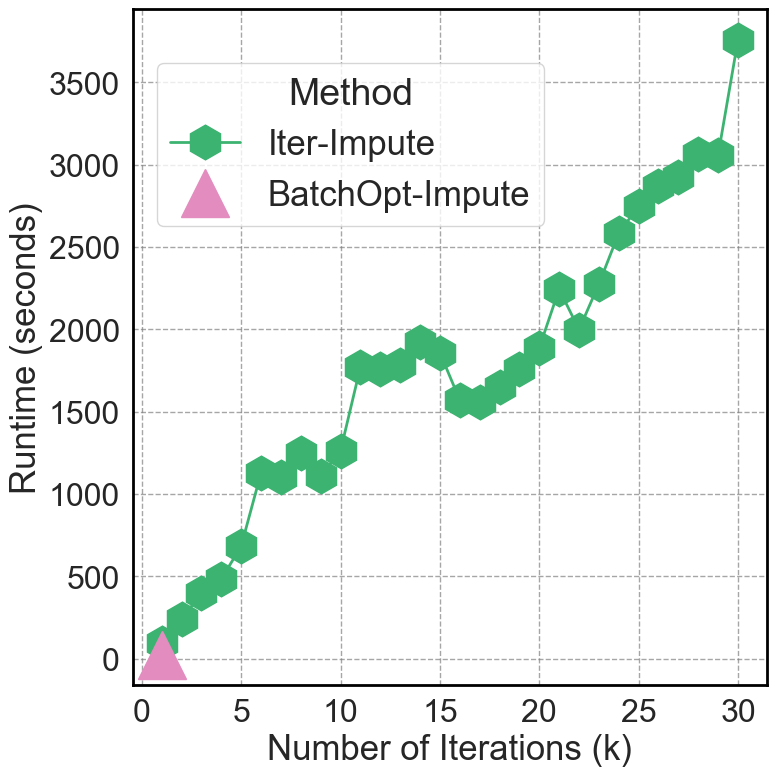

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="whitegrid", font_scale=1.2)

# Font and marker settings (match your style)
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
line_width = 2
marker_size = 15

# Colors
color_iterative = "#3CB371"        # Blue for Iterative
color_oneshotopt = "#e38cbf"       # Pink for OT-OneShotOpt

# Extract k and runtime for iterative ActiveFix
k_vals = df_iter_mcar["k"]
runtime_vals = df_iter_mcar["Runtime"]

# Extract OT-OneShotOpt runtime at 30% (single point)
runtime_oneshotopt_30 = results_mcar_opt_time["Time"]["OT-OneShotOpt"][0]

# Start the plot
plt.figure(figsize=(8, 8))

# Plot: Time vs Iteration for ActiveFix
plt.plot(
    k_vals, runtime_vals,
    label="Iter-Impute",
    marker='h',
    color=color_iterative,
    linewidth=line_width,
    markersize=25
)

# Plot: Single point for OT-OneShotOpt at k=1
plt.plot(
    1, runtime_oneshotopt_30,
    marker='^',
    color=color_oneshotopt,
    markersize=35,
    linestyle='None',
    label="BatchOpt-Impute"
)

# Axis labels and ticks
plt.xlabel("Number of Iterations (k)", fontsize=x_label_fontsize)
plt.ylabel("Runtime (seconds)", fontsize=y_label_fontsize)
plt.xticks(fontsize=x_tick_fontsize)
plt.yticks(fontsize=y_tick_fontsize)

# Border and grid
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

plt.grid(True, linestyle='--', color='gray', alpha=0.7)

# Legend
plt.legend(
    title="Method",
    fontsize=legend_label_fontsize,
    title_fontsize=legend_title_fontsize,
    loc="center left",
    bbox_to_anchor=(0.01,0.8),
    frameon=True
)

# Save and show
plt.tight_layout()
plt.savefig(
    r"C:\Users\zhossai3\Desktop\OT-Fix Imputation\Output\Runtime_Iterative_vs_OTOneShotOpt_k30.pdf",
    format="pdf",
    bbox_inches='tight'
)
plt.show()


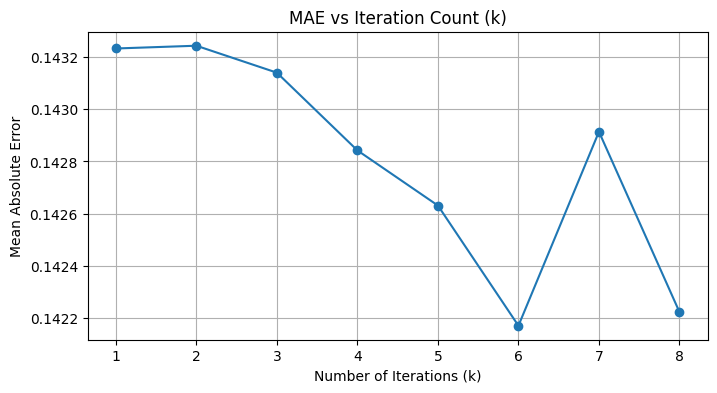

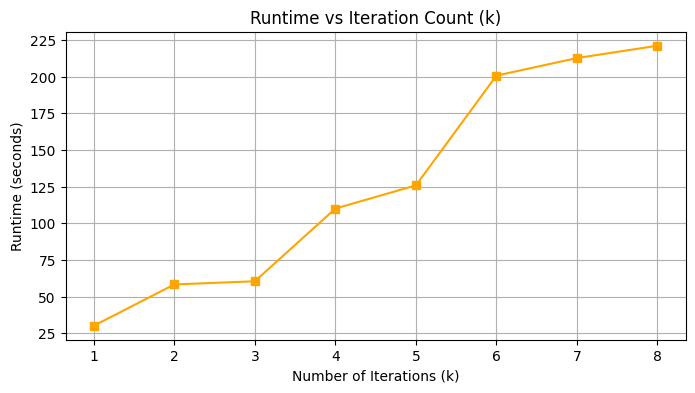

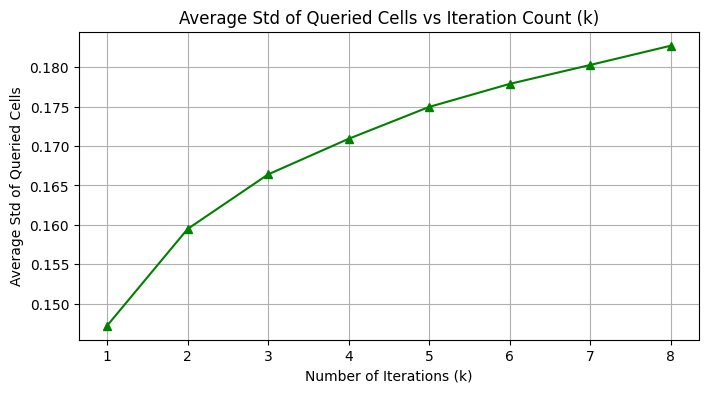

In [ ]:
# Plot MAE vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mcar['k'], df_iter_mcar['MAE'], marker='o', label='MAE')
plt.title("MAE vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Mean Absolute Error")
plt.grid(True)
plt.show()

# Plot Runtime vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mcar['k'], df_iter_mcar['Runtime'], marker='s', label='Runtime', color='orange')
plt.title("Runtime vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Runtime (seconds)")
plt.grid(True)
plt.show()

# Plot Avg Std vs Iteration Count (k)
plt.figure(figsize=(8, 4))
plt.plot(df_iter_mcar['k'], df_iter_mcar['AvgStdQueried'], marker='^', label='Avg Std of Queried', color='green')
plt.title("Average Std of Queried Cells vs Iteration Count (k)")
plt.xlabel("Number of Iterations (k)")
plt.ylabel("Average Std of Queried Cells")
plt.grid(True)
plt.show()

## Visualization

MAE vs Missingness among OT-Impute, OT-Rand, Batch-Impute

MCAR

Plotting results...
Saved plot for budget 10%


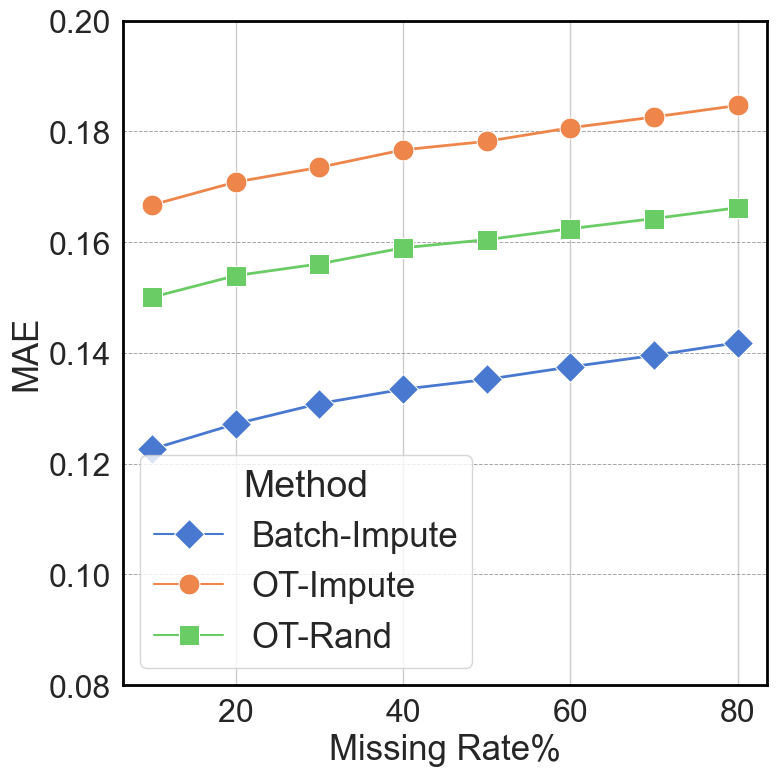

Saved plot for budget 20%


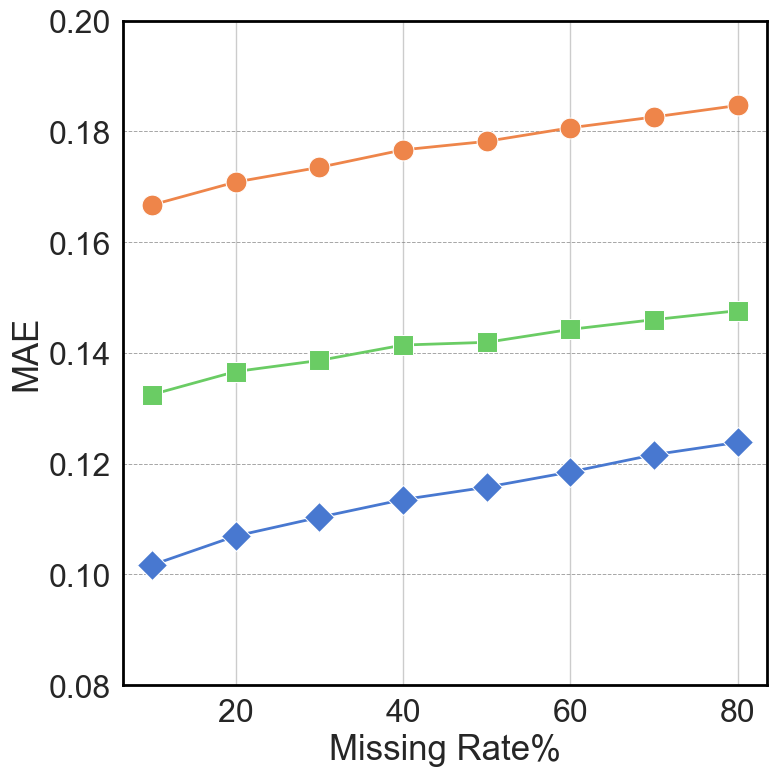

Saved plot for budget 30%


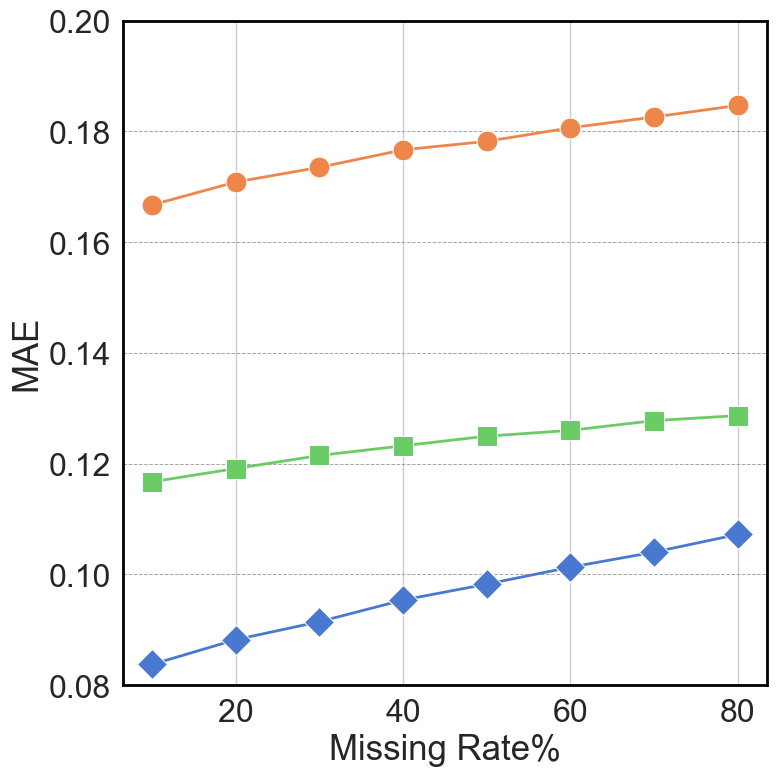

All plots generated successfully.


In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the experiment results
df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_results_mcar_metrics.csv")
df.columns = [ "MissingRate","Budget", "Method", "MAE", "MSE"]

# Plotting
print("Plotting results...")

# Filter to include only the required methods
methods_to_plot = ["OT-Impute", "OT-Rand", "Batch-Impute"]
df = df[df['Method'].isin(methods_to_plot)]
# Replace 'Index' with actual missing rate in percent
df["MissingRate"] = (df["MissingRate"] + 1) * 10


# Rename methods for clarity
#df['Method'] = df['Method'].replace({
    #"OT-Impute": "OT-Impute",
    #"OT + Random": "OT-Rand",
    #"OT + Confidence": "Batch-Impute"
#})

# Set fixed Y-axis range for all plots
y_min = 0.08
y_max = 0.20

# Custom font sizes
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
marker_size = 15

# Enforce font sizes with rcParams
plt.rcParams.update({
    'axes.titlesize': x_label_fontsize,
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

# Plot settings with the "muted" palette
sns.set(style="whitegrid", font_scale=1.2)
sns.set_palette("muted")  # Use the muted palette for slightly darker colors

# Define marker styles for each method
markers = {"OT-Impute": "o", "OT-Rand": "s", "Batch-Impute": "D"}  # Circle, square, diamond

for i, budget in enumerate([0.1, 0.2, 0.3]):
    plt.figure(figsize=(8, 8))  # Equal width and height
    subset = df[df['Budget'] == budget]
    
    # Create the line plot
    ax = sns.lineplot(
        data=subset, x="MissingRate", y="MAE", hue="Method", 
        style="Method", markers=markers, dashes=False, markersize=marker_size
    )
    
    # Set consistent Y-axis range
    plt.ylim(y_min, y_max)

    # Customize axis labels
    plt.xlabel("Missing Rate%", fontsize=x_label_fontsize)
    plt.ylabel("MAE", fontsize=y_label_fontsize)

    # Add legend only to the first plot
    if i == 0:
        plt.legend(title="Method", fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)
    else:
        ax.get_legend().remove()

    # Dark black borders on all four sides
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(2)

    # Adding small horizontal grid lines for y-axis values
    ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

    # Adjust the line and marker size
    for line in ax.lines:
        line.set_markersize(marker_size)  # Increased symbol size
        line.set_linewidth(2)

    # Set font size for X and Y axis tick labels
    ax.tick_params(axis='x', labelsize=x_tick_fontsize)
    ax.tick_params(axis='y', labelsize=y_tick_fontsize)

    # Adding small tick marks on the y-axis
    ax.yaxis.set_tick_params(width=1.5, length=5)

    # Save the plot as PDF without title
    plt.tight_layout()
    #plt.savefig(f"active_imputation_budget_{int(budget * 100)}.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(
    rf"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Cancer_MCAR_active_imputation_budget_{int(budget * 100)}.pdf",
    format="pdf",
    bbox_inches="tight"
)
    print(f"Saved plot for budget {int(budget * 100)}%")
    plt.show()
    plt.close()

print("All plots generated successfully.")

MAR

Plotting results...
Saved plot for budget 10%


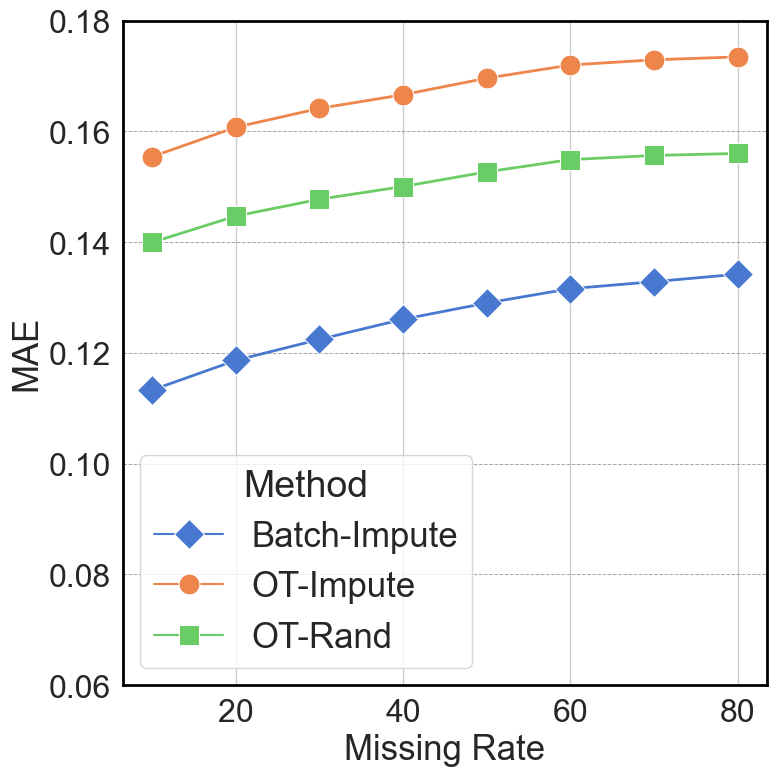

Saved plot for budget 20%


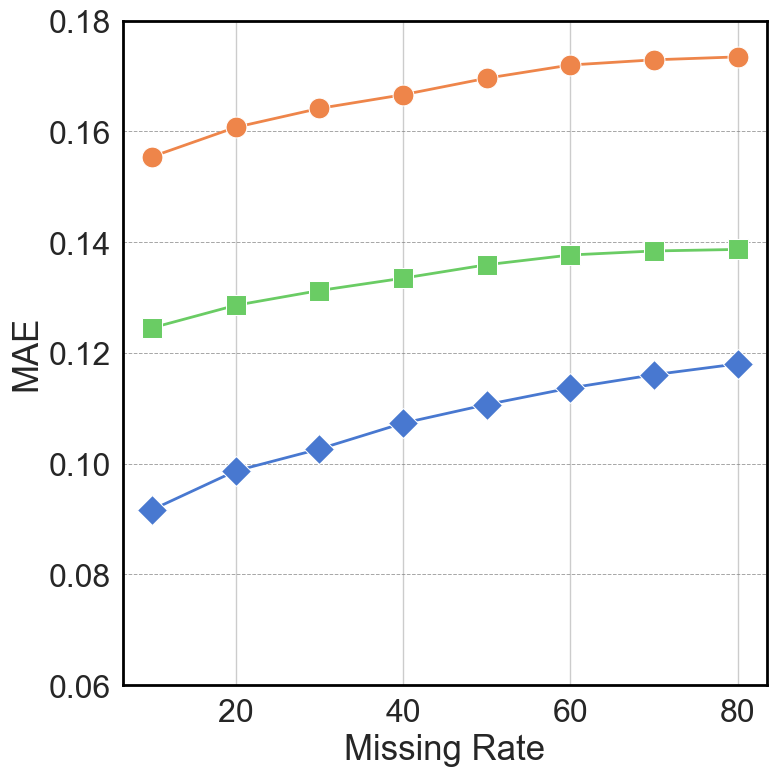

Saved plot for budget 30%


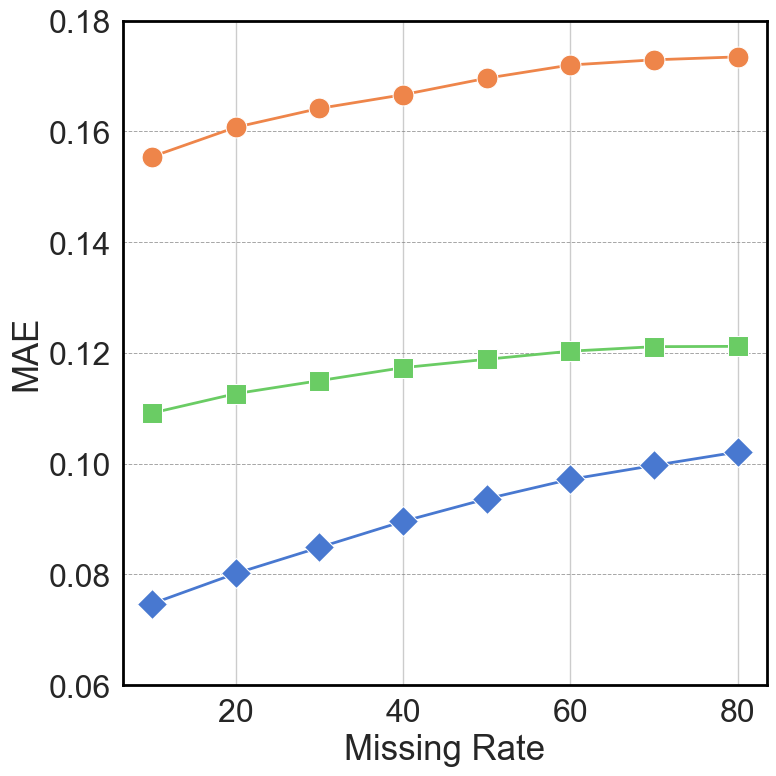

All plots generated successfully.


In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the experiment results
df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_results_mar_metrics.csv")
df.columns = [ "MissingRate","Budget", "Method", "MAE", "MSE"]

# Plotting
print("Plotting results...")

# Filter to include only the required methods
methods_to_plot = ["OT-Impute", "OT-Rand", "Batch-Impute"]
df = df[df['Method'].isin(methods_to_plot)]
# Replace 'Index' with actual missing rate in percent
df["MissingRate"] = (df["MissingRate"] + 1) * 10


# Rename methods for clarity
#df['Method'] = df['Method'].replace({
    #"OT-Impute": "OT-Impute",
    #"OT + Random": "OT-Rand",
    #"OT + Confidence": "Batch-Impute"
#})

# Set fixed Y-axis range for all plots
y_min = 0.06
y_max = 0.18

# Custom font sizes
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
marker_size = 15

# Enforce font sizes with rcParams
plt.rcParams.update({
    'axes.titlesize': x_label_fontsize,
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

# Plot settings with the "muted" palette
sns.set(style="whitegrid", font_scale=1.2)
sns.set_palette("muted")  # Use the muted palette for slightly darker colors

# Define marker styles for each method
markers = {"OT-Impute": "o", "OT-Rand": "s", "Batch-Impute": "D"}  # Circle, square, diamond

for i, budget in enumerate([0.1, 0.2, 0.3]):
    plt.figure(figsize=(8, 8))  # Equal width and height
    subset = df[df['Budget'] == budget]
    
    # Create the line plot
    ax = sns.lineplot(
        data=subset, x="MissingRate", y="MAE", hue="Method", 
        style="Method", markers=markers, dashes=False, markersize=marker_size
    )
    
    # Set consistent Y-axis range
    plt.ylim(y_min, y_max)

    # Customize axis labels
    plt.xlabel("Missing Rate", fontsize=x_label_fontsize)
    plt.ylabel("MAE", fontsize=y_label_fontsize)

    # Add legend only to the first plot
    if i == 0:
        plt.legend(title="Method", fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)
    else:
        ax.get_legend().remove()

    # Dark black borders on all four sides
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(2)

    # Adding small horizontal grid lines for y-axis values
    ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

    # Adjust the line and marker size
    for line in ax.lines:
        line.set_markersize(marker_size)  # Increased symbol size
        line.set_linewidth(2)

    # Set font size for X and Y axis tick labels
    ax.tick_params(axis='x', labelsize=x_tick_fontsize)
    ax.tick_params(axis='y', labelsize=y_tick_fontsize)

    # Adding small tick marks on the y-axis
    ax.yaxis.set_tick_params(width=1.5, length=5)

    # Save the plot as PDF without title
    plt.tight_layout()
    #plt.savefig(f"active_imputation_budget_{int(budget * 100)}.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(
    rf"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Cancer_MAR_active_imputation_budget_{int(budget * 100)}.pdf",
    format="pdf",
    bbox_inches="tight"
)
    print(f"Saved plot for budget {int(budget * 100)}%")
    plt.show()
    plt.close()

print("All plots generated successfully.")

MNAR

Plotting results...
Saved plot for budget 10%


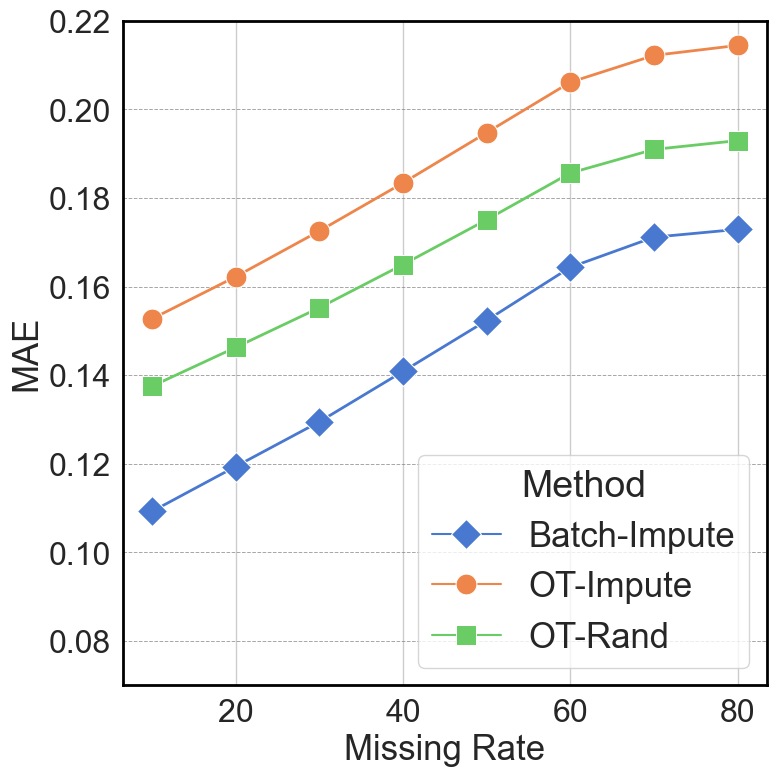

Saved plot for budget 20%


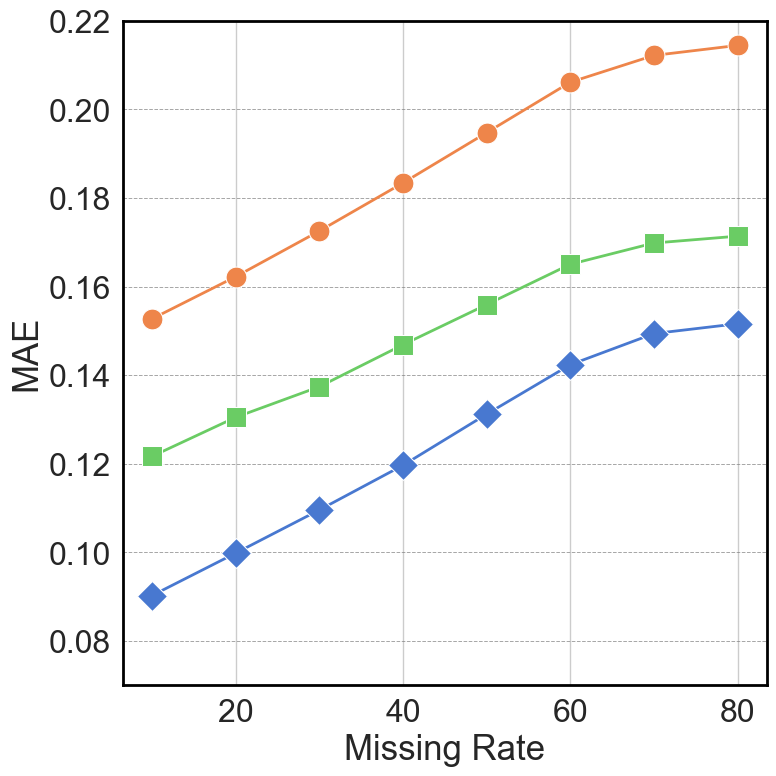

Saved plot for budget 30%


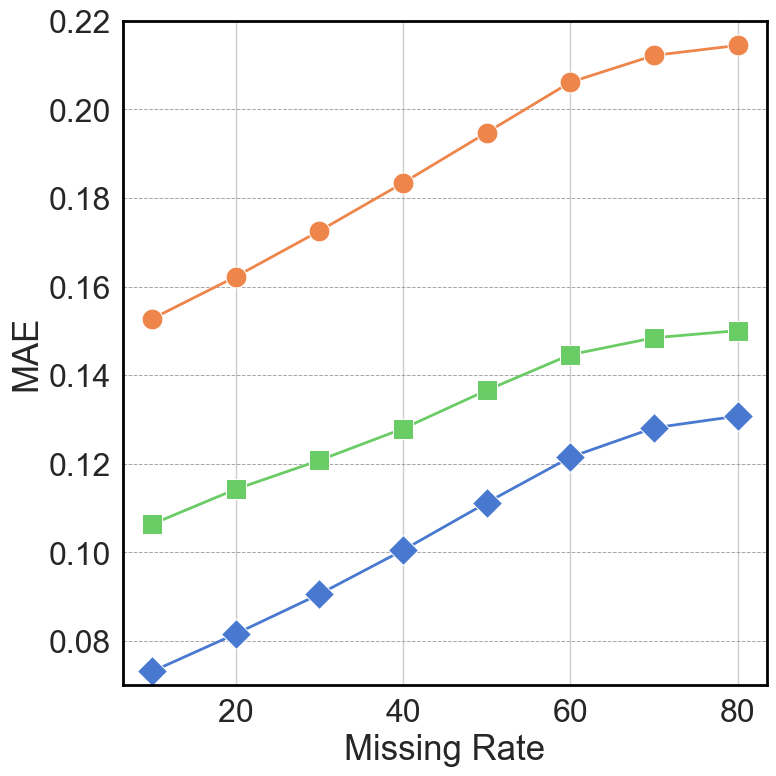

All plots generated successfully.


In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the experiment results
df = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_results_mnar_metrics.csv")
df.columns = [ "MissingRate","Budget", "Method", "MAE", "MSE"]

# Plotting
print("Plotting results...")

# Filter to include only the required methods
methods_to_plot = ["OT-Impute", "OT-Rand", "Batch-Impute"]
df = df[df['Method'].isin(methods_to_plot)]
# Replace 'Index' with actual missing rate in percent
df["MissingRate"] = (df["MissingRate"] + 1) * 10


# Rename methods for clarity
#df['Method'] = df['Method'].replace({
    #"OT-Impute": "OT-Impute",
    #"OT + Random": "OT-Rand",
    #"OT + Confidence": "Batch-Impute"
#})

# Set fixed Y-axis range for all plots
y_min = 0.07
y_max = 0.22

# Custom font sizes
x_label_fontsize = 25
y_label_fontsize = 25
x_tick_fontsize = 23
y_tick_fontsize = 23
legend_title_fontsize = 27
legend_label_fontsize = 25
marker_size = 15

# Enforce font sizes with rcParams
plt.rcParams.update({
    'axes.titlesize': x_label_fontsize,
    'axes.labelsize': y_label_fontsize,
    'xtick.labelsize': x_tick_fontsize,
    'ytick.labelsize': y_tick_fontsize,
    'legend.fontsize': legend_label_fontsize,
    'legend.title_fontsize': legend_title_fontsize
})

# Plot settings with the "muted" palette
sns.set(style="whitegrid", font_scale=1.2)
sns.set_palette("muted")  # Use the muted palette for slightly darker colors

# Define marker styles for each method
markers = {"OT-Impute": "o", "OT-Rand": "s", "Batch-Impute": "D"}  # Circle, square, diamond

for i, budget in enumerate([0.1, 0.2, 0.3]):
    plt.figure(figsize=(8, 8))  # Equal width and height
    subset = df[df['Budget'] == budget]
    
    # Create the line plot
    ax = sns.lineplot(
        data=subset, x="MissingRate", y="MAE", hue="Method", 
        style="Method", markers=markers, dashes=False, markersize=marker_size
    )
    
    # Set consistent Y-axis range
    plt.ylim(y_min, y_max)

    # Customize axis labels
    plt.xlabel("Missing Rate", fontsize=x_label_fontsize)
    plt.ylabel("MAE", fontsize=y_label_fontsize)

    # Add legend only to the first plot
    if i == 0:
        plt.legend(title="Method", fontsize=legend_label_fontsize, title_fontsize=legend_title_fontsize)
    else:
        ax.get_legend().remove()

    # Dark black borders on all four sides
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(2)

    # Adding small horizontal grid lines for y-axis values
    ax.yaxis.grid(True, linestyle='--', color='grey', linewidth=0.7, alpha=0.7)

    # Adjust the line and marker size
    for line in ax.lines:
        line.set_markersize(marker_size)  # Increased symbol size
        line.set_linewidth(2)

    # Set font size for X and Y axis tick labels
    ax.tick_params(axis='x', labelsize=x_tick_fontsize)
    ax.tick_params(axis='y', labelsize=y_tick_fontsize)

    # Adding small tick marks on the y-axis
    ax.yaxis.set_tick_params(width=1.5, length=5)

    # Save the plot as PDF without title
    plt.tight_layout()
    #plt.savefig(f"active_imputation_budget_{int(budget * 100)}.pdf", format="pdf", bbox_inches="tight")
    plt.savefig(
    rf"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Cancer_MNAR_active_imputation_budget_{int(budget * 100)}.pdf",
    format="pdf",
    bbox_inches="tight"
)
    print(f"Saved plot for budget {int(budget * 100)}%")
    plt.show()
    plt.close()

print("All plots generated successfully.")

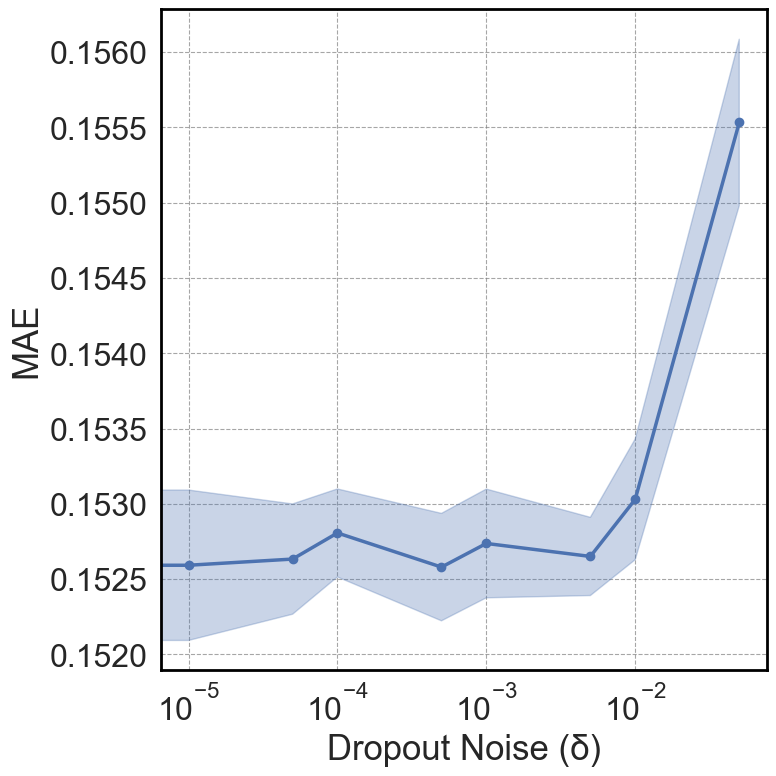

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import LogFormatterMathtext

# Load the CSV
df_dropout = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_MCAR_DropoutNoise_MAE_Results.csv")
df_dropout["DropoutNoise"] = pd.to_numeric(df_dropout["DropoutNoise"], errors='coerce')
df_dropout["MAE"] = pd.to_numeric(df_dropout["MAE"], errors='coerce')
df_dropout = df_dropout.dropna(subset=["DropoutNoise", "MAE"])

# Dropout values to include
dropOutNoises = [0.0, 0.00001, 0.00005, 0.0001, 0.0005,
                 0.001, 0.005, 0.01, 0.05]

# Filter and compute mean + std
df_line = (
    df_dropout[df_dropout["DropoutNoise"].isin(dropOutNoises)]
    .groupby("DropoutNoise")["MAE"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("DropoutNoise")
)

# Plot styling
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(8, 8))

# Line + shaded area
plt.plot(
    df_line["DropoutNoise"], df_line["mean"],
    marker='o', color="#4c72b0", linewidth=2.5, markersize=6
)
plt.fill_between(
    df_line["DropoutNoise"],
    df_line["mean"] - df_line["std"],
    df_line["mean"] + df_line["std"],
    alpha=0.3,
    color="#4c72b0"
)

# Log scale and scientific ticks
plt.xscale("log")
plt.gca().xaxis.set_major_formatter(LogFormatterMathtext())

# Labels
plt.xlabel("Dropout Noise (δ)", fontsize=25, labelpad=5)
plt.ylabel("MAE", fontsize=25, labelpad=5)

# Ticks and rotation
plt.xticks(fontsize=23, rotation=0)
plt.yticks(fontsize=23)

# Grid and border
plt.grid(True, linestyle='--', color='gray', linewidth=0.8, alpha=0.7)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Optional: plot title below if for LaTeX
# plt.title(r"(b) MAE vs $\delta$ (MCAR, 30%)", fontsize=22, y=-0.25)

# Save + show
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Cancer_MCAR_DropoutNoise_LogPlot.pdf", bbox_inches='tight')
plt.show()


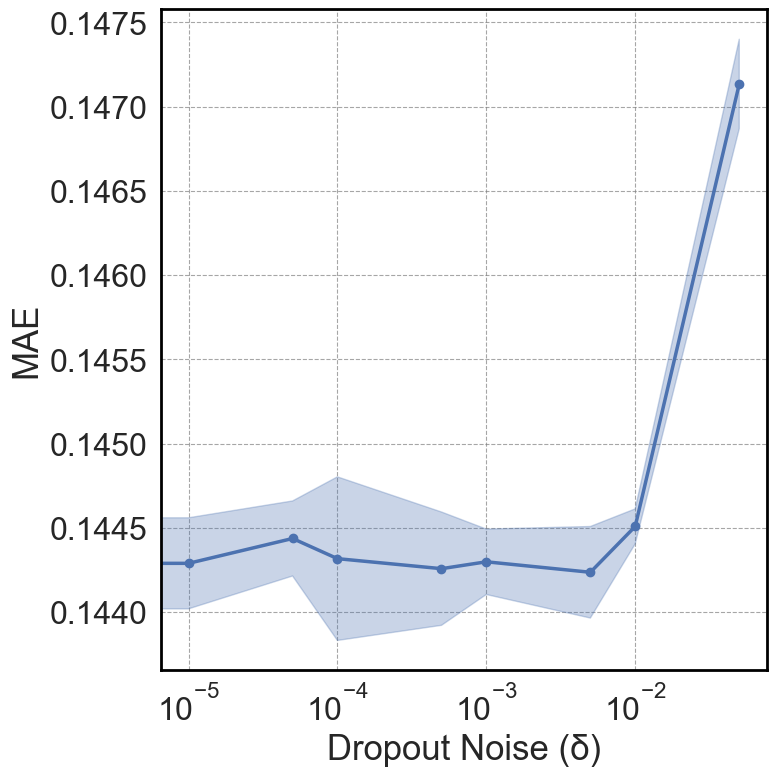

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import LogFormatterMathtext

# Load the CSV
df_dropout = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_MAR_DropoutNoise_MAE_Results.csv")
df_dropout["DropoutNoise"] = pd.to_numeric(df_dropout["DropoutNoise"], errors='coerce')
df_dropout["MAE"] = pd.to_numeric(df_dropout["MAE"], errors='coerce')
df_dropout = df_dropout.dropna(subset=["DropoutNoise", "MAE"])

# Dropout values to include
dropOutNoises = [0.0, 0.00001, 0.00005, 0.0001, 0.0005,
                 0.001, 0.005, 0.01, 0.05]

# Filter and compute mean + std
df_line = (
    df_dropout[df_dropout["DropoutNoise"].isin(dropOutNoises)]
    .groupby("DropoutNoise")["MAE"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("DropoutNoise")
)

# Plot styling
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(8, 8))

# Line + shaded area
plt.plot(
    df_line["DropoutNoise"], df_line["mean"],
    marker='o', color="#4c72b0", linewidth=2.5, markersize=6
)
plt.fill_between(
    df_line["DropoutNoise"],
    df_line["mean"] - df_line["std"],
    df_line["mean"] + df_line["std"],
    alpha=0.3,
    color="#4c72b0"
)

# Log scale and scientific ticks
plt.xscale("log")
plt.gca().xaxis.set_major_formatter(LogFormatterMathtext())

# Labels
plt.xlabel("Dropout Noise (δ)", fontsize=25, labelpad=5)
plt.ylabel("MAE", fontsize=25, labelpad=5)

# Ticks and rotation
plt.xticks(fontsize=23, rotation=0)
plt.yticks(fontsize=23)

# Grid and border
plt.grid(True, linestyle='--', color='gray', linewidth=0.8, alpha=0.7)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Optional: plot title below if for LaTeX
# plt.title(r"(b) MAE vs $\delta$ (MCAR, 30%)", fontsize=22, y=-0.25)

# Save + show
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Cancer_MAR_DropoutNoise_LogPlot.pdf", bbox_inches='tight')
plt.show()


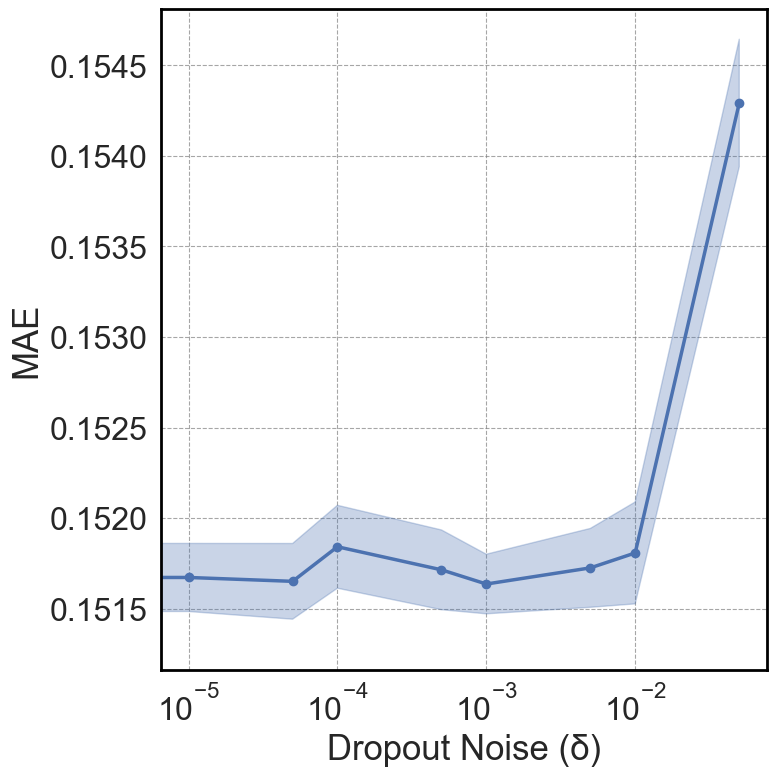

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import LogFormatterMathtext

# Load the CSV
df_dropout = pd.read_csv(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\results\Cancer_MNAR_DropoutNoise_MAE_Results.csv")
df_dropout["DropoutNoise"] = pd.to_numeric(df_dropout["DropoutNoise"], errors='coerce')
df_dropout["MAE"] = pd.to_numeric(df_dropout["MAE"], errors='coerce')
df_dropout = df_dropout.dropna(subset=["DropoutNoise", "MAE"])

# Dropout values to include
dropOutNoises = [0.0, 0.00001, 0.00005, 0.0001, 0.0005,
                 0.001, 0.005, 0.01, 0.05]

# Filter and compute mean + std
df_line = (
    df_dropout[df_dropout["DropoutNoise"].isin(dropOutNoises)]
    .groupby("DropoutNoise")["MAE"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("DropoutNoise")
)

# Plot styling
sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(8, 8))

# Line + shaded area
plt.plot(
    df_line["DropoutNoise"], df_line["mean"],
    marker='o', color="#4c72b0", linewidth=2.5, markersize=6
)
plt.fill_between(
    df_line["DropoutNoise"],
    df_line["mean"] - df_line["std"],
    df_line["mean"] + df_line["std"],
    alpha=0.3,
    color="#4c72b0"
)

# Log scale and scientific ticks
plt.xscale("log")
plt.gca().xaxis.set_major_formatter(LogFormatterMathtext())

# Labels
plt.xlabel("Dropout Noise (δ)", fontsize=25, labelpad=5)
plt.ylabel("MAE", fontsize=25, labelpad=5)

# Ticks and rotation
plt.xticks(fontsize=23, rotation=0)
plt.yticks(fontsize=23)

# Grid and border
plt.grid(True, linestyle='--', color='gray', linewidth=0.8, alpha=0.7)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(2)

# Optional: plot title below if for LaTeX
# plt.title(r"(b) MAE vs $\delta$ (MCAR, 30%)", fontsize=22, y=-0.25)

# Save + show
plt.tight_layout()
plt.savefig(r"C:\Users\zhossai3\Desktop\Active Imputation\active_imputation\Output\Cancer_MNAR_DropoutNoise_LogPlot.pdf", bbox_inches='tight')
plt.show()
